=== ratio 4:1 (I_crit1 : I_crit2), noise/thermal OFF ===


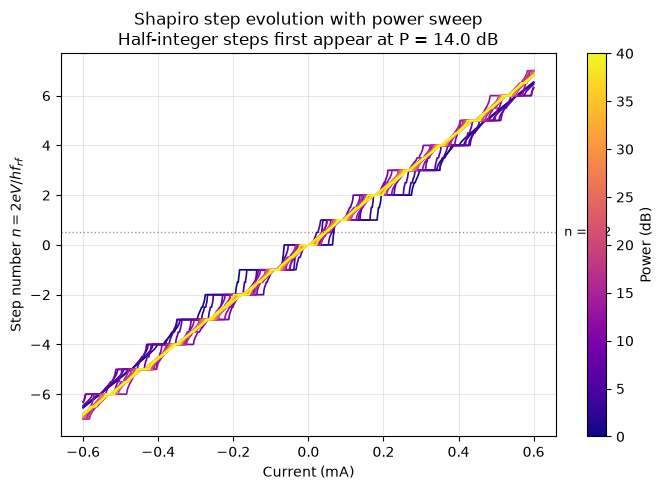

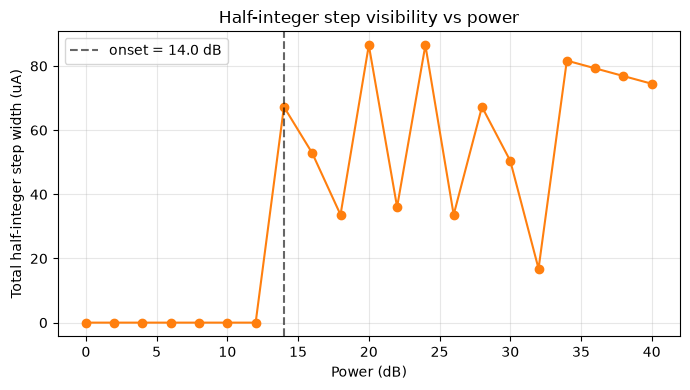

Half-integer steps first appear (and stay flat) around P = 14.0 dB.
=== ratio 3:2 (I_crit1 : I_crit2), noise/thermal OFF ===


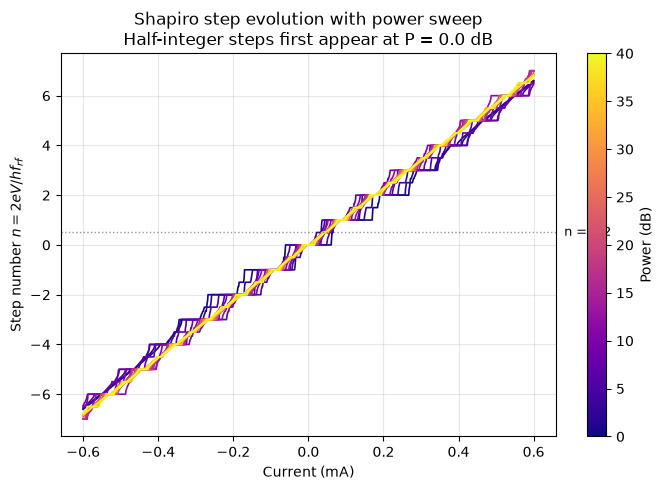

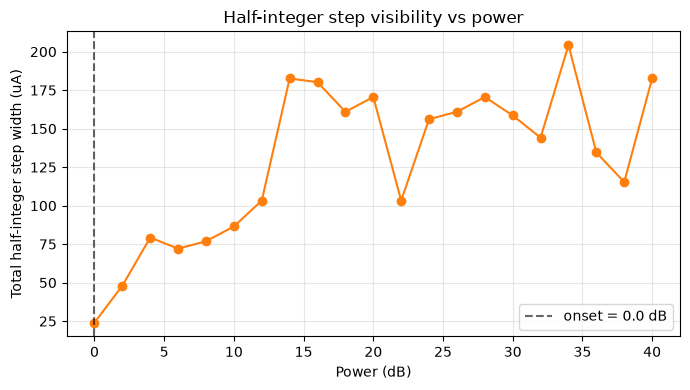

Half-integer steps first appear (and stay flat) around P = 0.0 dB.


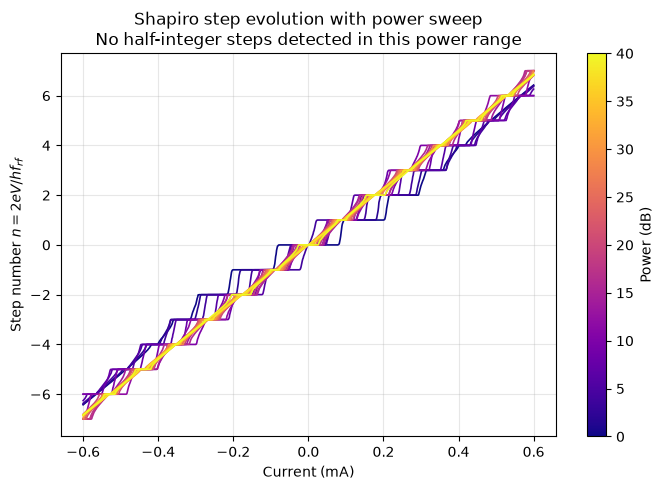

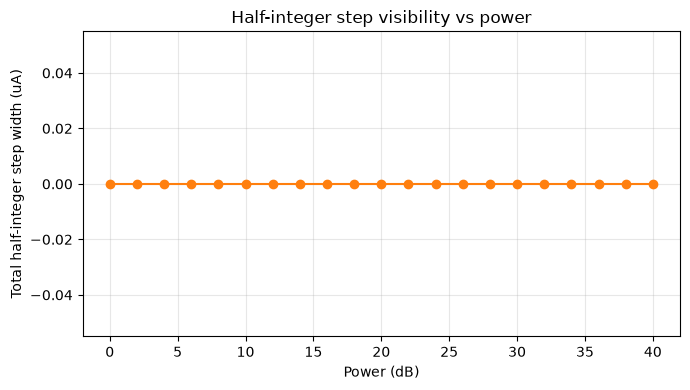

No half-integer steps detected in this power range.
Ratio I2/I_total = 0.00 → no visible half steps


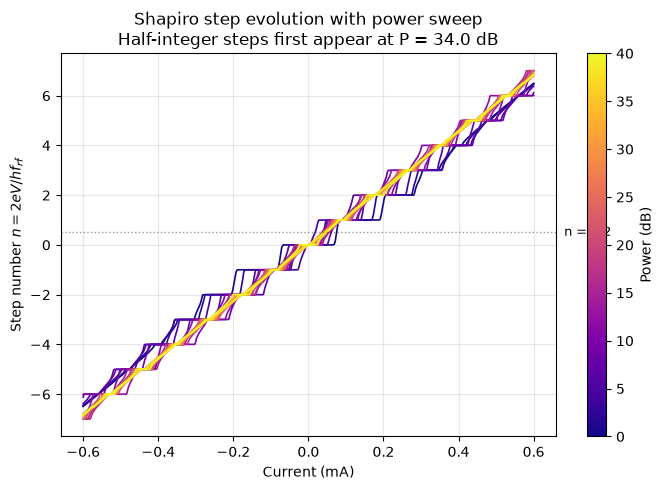

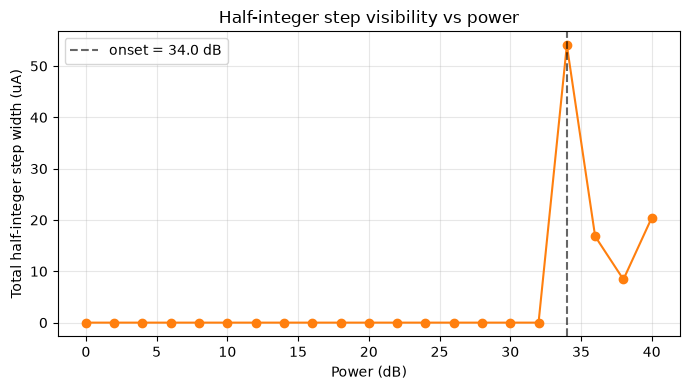

Half-integer steps first appear (and stay flat) around P = 34.0 dB.
Ratio I2/I_total = 0.10 → onset power = 34.0 dB


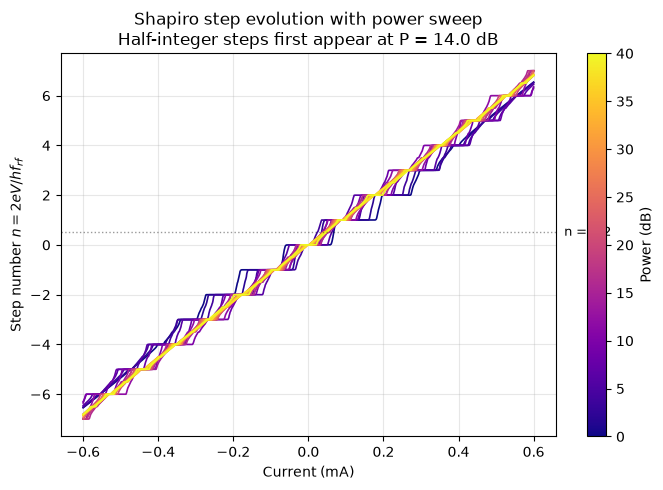

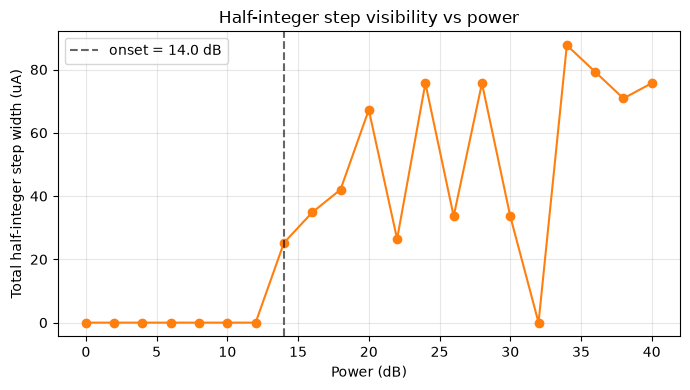

Half-integer steps first appear (and stay flat) around P = 14.0 dB.
Ratio I2/I_total = 0.20 → onset power = 14.0 dB


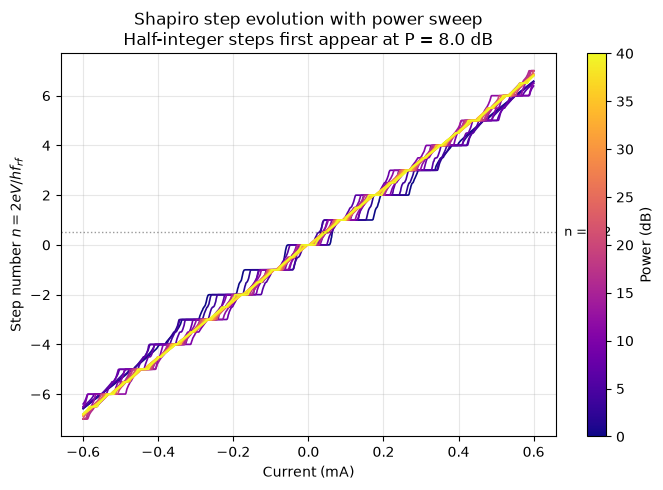

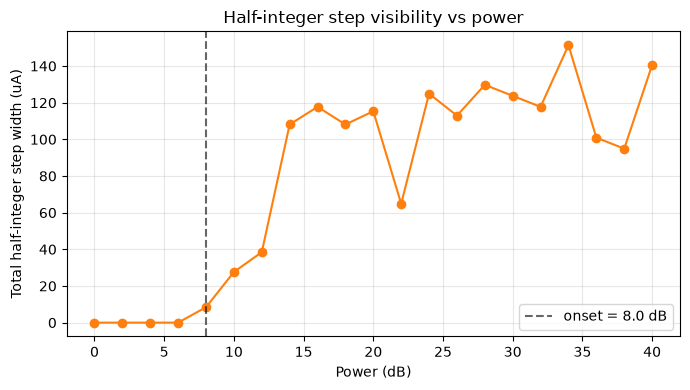

Half-integer steps first appear (and stay flat) around P = 8.0 dB.
Ratio I2/I_total = 0.30 → onset power = 8.0 dB


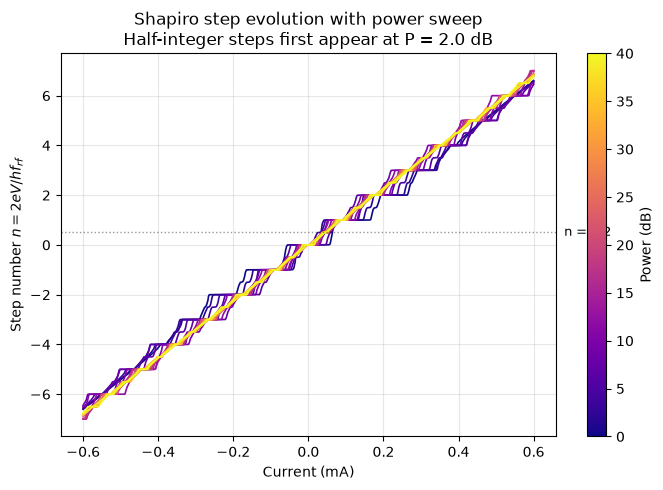

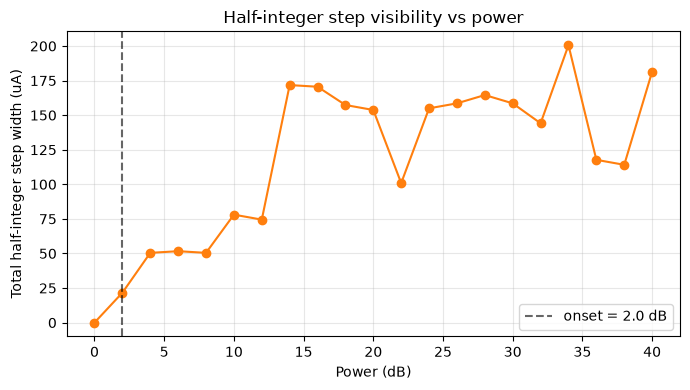

Half-integer steps first appear (and stay flat) around P = 2.0 dB.
Ratio I2/I_total = 0.40 → onset power = 2.0 dB


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

kb = 1.380649e-23
e = 1.602176634e-19
hbar = 1.054571817e-34


# ------------------------------------------------------------
# 1. Two-harmonic RSJ/RCSJ simulator
# ------------------------------------------------------------
def simulate_IV_RCSJ_two_harmonics(
        R, I_crit1, I_crit2, frequency, power, I0, c_calib, noise,
        C, T, n_periods,
        steps_per_period=200, n_transient_periods=50):

    Irf_val = c_calib * (I_crit1 + I_crit2) * 10 ** ((power) / 20)

    dt = (1.0 / frequency) / steps_per_period
    n_steps = int(n_periods * steps_per_period)
    n_transient = int(n_transient_periods * steps_per_period)

    I0 = np.asarray(I0, dtype=float)
    phi = np.zeros_like(I0)
    dphidt = np.zeros_like(I0)
    V_sum = np.zeros_like(I0)
    count = 0
    t = 0.0

    noise_T_amp = np.sqrt(2 * kb * T / (R * dt)) if T > 0 else 0.0

    for s in range(n_steps):
        I_N = noise_T_amp * np.random.randn(I0.size) if T > 0 else 0.0     ## johnson nyquist noise
        I_F = (noise * np.random.randn(I0.size) * (I0 + Irf_val / 1000.0)  ## random fluctuating noise
               if noise > 0 else 0.0)

        I_s = I_crit1 * np.sin(phi) + I_crit2 * np.sin(2.0 * phi)          ## 2nd harmonic contribution

        I_drive = I0 + Irf_val * np.sin(2.0 * np.pi * frequency * t) - I_s + I_N + I_F  ## drive frequency

        ###### with capacitance ######################################################
        if C > 0:
            d2phidt2 = (2.0 * e / (hbar * C)) * I_drive - dphidt / (R * C)
            dphidt = dphidt + dt * d2phidt2
        ###### without          ######################################################
        else:
            dphidt = (2.0 * e * R / hbar) * I_drive

        phi = phi + dt * dphidt

        if s >= n_transient:
            V_sum += (hbar / (2.0 * e)) * dphidt
            count += 1

        t += dt

    v_avg = V_sum / count
    nth_step = (v_avg * 2.0 * e) / (hbar * 2.0 * np.pi * frequency)

    return nth_step, v_avg                                             ## return the step number and the average over the voltages


####### extract the step positions #############################################################################

def extract_integer_and_half_steps(I0, nth_step, tol=0.05, min_points=8,
                                    flatness_tol=None):
    if flatness_tol is None:
        flatness_tol = tol / 2.0

    I0 = np.asarray(I0)
    nth_step = np.asarray(nth_step)

    nearest_half = np.round(2.0 * nth_step) / 2.0
    residual = np.abs(nth_step - nearest_half)
    on_plateau = residual < tol

    widths = {}
    ranges = {}

    i = 0
    N = len(I0)
    while i < N:
        if not on_plateau[i]:
            i += 1
            continue

        n_val = nearest_half[i]
        j = i
        while j < N and on_plateau[j] and nearest_half[j] == n_val:
            j += 1

        if (j - i) >= min_points:
            segment = nth_step[i:j]
            if np.std(segment) < flatness_tol:
                I0_min = I0[i]
                I0_max = I0[j - 1]
                width = I0_max - I0_min

                if n_val not in widths or width > widths[n_val]:
                    widths[n_val] = width
                    ranges[n_val] = (I0_min, I0_max)

        i = j

    return widths, ranges


def has_half_integer_step(widths):
    """True if any of the extracted plateaus is a genuine half-integer
    (not integer) step index."""
    return any(not np.isclose(n, np.round(n)) for n in widths)


####### power sweep ####################################################################################
def scan_power_and_plot_half_steps(
        R, I_crit1, I_crit2, frequency, I0, c_calib,
        noise, C, T, n_periods,
        power_values, tol=0.05, min_points=8, flatness_tol=None,
        require_consecutive=1):
    """
    vary the rf power then use the step extraction function to detect the steps for each power

    """
    fig, ax = plt.subplots(figsize=(7, 5))
    cmap = plt.get_cmap("plasma")
    norm = plt.Normalize(min(power_values), max(power_values))

    results = {}
    hit_flags = []

    for P in power_values:
        nth_step, v_avg = simulate_IV_RCSJ_two_harmonics(          ## call simulation function
            R, I_crit1, I_crit2, frequency, P, I0, c_calib,
            noise, C, T, n_periods
        )
        widths, ranges = extract_integer_and_half_steps(           ## extract the widths
            I0, nth_step, tol=tol, min_points=min_points,
            flatness_tol=flatness_tol)

        results[P] = (nth_step, v_avg, widths, ranges)             ## get the results for each power
        hit_flags.append(has_half_integer_step(widths))

        color = cmap(norm(P))
        ax.plot(I0 * 1e3, nth_step, color=color, lw=1.2)

    ## find first power where there are consecutive flat values of the voltage
    onset_power = None
    powers_sorted = sorted(power_values)
    hit_by_power = dict(zip(power_values, hit_flags))
    hits_sorted = [hit_by_power[P] for P in powers_sorted]
    
    for idx in range(len(hits_sorted) - require_consecutive + 1):
        if all(hits_sorted[idx:idx + require_consecutive]):
            onset_power = powers_sorted[idx]
            break

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Power (dB)")

    if onset_power is not None:

        ax.axhline(0.5, color='k', linestyle=':', alpha=0.4, lw=1)
        ax.text(ax.get_xlim()[1], 0.5, "  n = 1/2", va='center', fontsize=9)
        ax.set_title(
            f"Shapiro step evolution with power sweep\n"
            f"Half-integer steps first appear at P = {onset_power:.1f} dB"
        )
    else:
        ax.set_title("Shapiro step evolution with power sweep\n"
                      "No half-integer steps detected in this power range")

    ax.set_xlabel("Current (mA)")
    ax.set_ylabel(r"Step number $n = 2eV/hf_{rf}$")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    ## plot the step power against the number of steps
    powers_arr = np.array(powers_sorted)
    half_metric = []
    for P in powers_sorted:
        _, _, widths, _ = results[P]
        half_ns = [n for n in widths if not np.isclose(n, np.round(n))]
        half_metric.append(sum(widths[n] for n in half_ns) * 1e6 if half_ns else 0.0)
    half_metric = np.array(half_metric)

    plt.figure(figsize=(7, 4))
    plt.plot(powers_arr, half_metric, 'o-', color='tab:orange')
    if onset_power is not None:
        plt.axvline(onset_power, color='k', linestyle='--', alpha=0.6,
                    label=f"onset = {onset_power:.1f} dB")
        plt.legend()
    plt.xlabel("Power (dB)")
    plt.ylabel("Total half-integer step width (uA)")
    plt.title("Half-integer step visibility vs power")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    if onset_power is not None:
        print(f"Half-integer steps first appear (and stay flat) around "
              f"P = {onset_power:.1f} dB.")
    else:
        print("No half-integer steps detected in this power range.")

    return results, onset_power


## practice run 

junction = dict(
        R=0.1017,
        I_crit=0.191e-3,
        frequency=4340e6,
        I0=np.linspace(-0.6e-3, 0.6e-3, 1000)
    )

powers = np.linspace(0, 40, 21)

## practice with temperature and noise = 0
print("=== ratio 4:1 (I_crit1 : I_crit2), noise/thermal OFF ===")
results_41, onset_41 = scan_power_and_plot_half_steps(
        R=junction["R"],
        I_crit1=0.8 * junction["I_crit"],
        I_crit2=0.2 * junction["I_crit"],
        frequency=junction["frequency"],
        I0=junction["I0"],
        c_calib=1.0,
        noise=0.0,
        C=0.0,
        T=0.0,
        n_periods=500,
        power_values=powers,
    )

print("=== ratio 3:2 (I_crit1 : I_crit2), noise/thermal OFF ===")
results_32, onset_32 = scan_power_and_plot_half_steps(
        R=junction["R"],
        I_crit1=0.6 * junction["I_crit"],
        I_crit2=0.4 * junction["I_crit"],
        frequency=junction["frequency"],
        I0=junction["I0"],
        c_calib=1.0,
        noise=0.0,
        C=0.0,
        T=0.0,
        n_periods=500,
        power_values=powers,
    )

def scan_ratios_and_detect_onset(
        R, I_crit_total, frequency, I0, c_calib,
        noise, C, T, n_periods,
        power_values, ratio_values,
        tol=0.05, min_points=8, flatness_tol=None,
        require_consecutive=1, noise_threshold=1e-6):
    """
    function to sweep the ratios between the first and second harmonic contributions

    Parameters
    ----------
    ratio_values : array-like
        Fractional contribution of the second harmonic (I_crit2 / I_crit_total).
    noise_threshold : float
        = the minimum noise level at which the half integer steps are observed

    return:
    onset_map : dict {ratio -> onset_power or None}
    half_widths : dict {ratio -> array of total half-step widths vs power}
    """

    onset_map = {}
    half_widths = {}

    for r in ratio_values:                  ## get the values of each critical current given a certain ratio
        I_crit1 = (1 - r) * I_crit_total
        I_crit2 = r * I_crit_total

        results, onset_power = scan_power_and_plot_half_steps(     ## call function
            R=R,
            I_crit1=I_crit1,
            I_crit2=I_crit2,
            frequency=frequency,
            I0=I0,
            c_calib=c_calib,
            noise=noise,
            C=C,
            T=T,
            n_periods=n_periods,
            power_values=power_values,
            tol=tol,
            min_points=min_points,
            flatness_tol=flatness_tol,
            require_consecutive=require_consecutive,
        )


        powers_sorted = sorted(power_values)                                 ## quantify the steps at each power
        widths_vs_power = []
        for P in powers_sorted:
            _, _, widths, _ = results[P]
            half_ns = [n for n in widths if not np.isclose(n, np.round(n))]
            total_half_width = sum(widths[n] for n in half_ns)
            widths_vs_power.append(total_half_width)

        half_widths[r] = np.array(widths_vs_power)

        
        #### find the onset above the noise threshhold #################################
        visible = np.array(widths_vs_power) > noise_threshold            
        onset_idx = np.argmax(visible)
        onset_map[r] = powers_sorted[onset_idx] if visible.any() else None

        print(f"Ratio I2/I_total = {r:.2f} → onset power = "
              f"{onset_map[r]:.1f} dB" if onset_map[r] else
              f"Ratio I2/I_total = {r:.2f} → no visible half steps")

    ############ Plotting ##################################################################
    plt.figure(figsize=(7, 4))
    ratios = np.array(list(onset_map.keys()))
    onsets = np.array([onset_map[r] if onset_map[r] is not None else np.nan
                       for r in ratios])
    plt.plot(ratios, onsets, 'o-', color='tab:red')
    plt.xlabel("Second harmonic ratio (I₂ / I_total)")
    plt.ylabel("Onset power (dB)")
    plt.title("Half-integer step onset vs harmonic ratio")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return onset_map, half_widths

### call the functions for jucntion 1
junction = dict(
        R=0.1017,
        I_crit=0.191e-3,
        frequency=4340e6,
        I0=np.linspace(-0.6e-3, 0.6e-3, 1000)
    )

powers = np.linspace(0, 40, 21)
ratios = np.linspace(0.0, 1, 11)  # vary second harmonic strength

onset_map, half_widths = scan_ratios_and_detect_onset(
        R=junction["R"],
        I_crit_total=junction["I_crit"],
        frequency=junction["frequency"],
        I0=junction["I0"],
        c_calib=1.0,
        noise=1e-6,  # dimensionless noise parameter
        C=0.0,
        T=4.2,
        n_periods=500,
        power_values=powers,
        ratio_values=ratios,
        noise_threshold=5e-6,  ## small noise threshhold (microamps)
    )


def sweep_ratios_and_summarize(
        R, I_crit_total, frequency, I0, c_calib,
        noise, C, T, n_periods,
        power_values, ratio_values,
        tol=0.05, min_points=8, flatness_tol=None,
        require_consecutive=1,
        noise_threshold=5e-6):
    """
    For each harmonic ratio r = I_crit2 / I_crit_total:
      - sweep powers
      - detect half-integer onset above noise threshold
      - record width of first half-integer step
      - compute Bessel prediction for ΔI_1/2
      - return a summary table

    Returns
    -------
    summary : list of dicts
        Each dict contains:
            ratio
            onset_power
            first_half_width
            bessel_predicted_width
    """

    summary = []

    for r in ratio_values:
        I_crit2 = r * I_crit_total
        I_crit1 = (1 - r) * I_crit_total

        # Run your existing power sweep
        results, onset_power = scan_power_and_plot_half_steps(
            R=R,
            I_crit1=I_crit1,
            I_crit2=I_crit2,
            frequency=frequency,
            I0=I0,
            c_calib=c_calib,
            noise=noise,
            C=C,
            T=T,
            n_periods=n_periods,
            power_values=power_values,
            tol=tol,
            min_points=min_points,
            flatness_tol=flatness_tol,
            require_consecutive=require_consecutive,
        )

        # Compute half-step widths vs power
        powers_sorted = sorted(power_values)
        half_widths = []
        for P in powers_sorted:
            _, _, widths, _ = results[P]
            half_ns = [n for n in widths if not np.isclose(n, np.round(n))]
            total_half_width = sum(widths[n] for n in half_ns)
            half_widths.append(total_half_width)

        half_widths = np.array(half_widths)

        # Detect onset above noise threshold
        visible = half_widths > noise_threshold
        if visible.any():
            idx = np.argmax(visible)
            onset = powers_sorted[idx]
            first_width = half_widths[idx]
        else:
            onset = None
            first_width = 0.0

        # Bessel prediction for ΔI_1/2
        # RF amplitude model from your simulator:
        # Irf = c_calib * (I_crit1 + I_crit2) * 10^((P - 20)/20)
        import scipy.special as sp

        if onset is not None:
            Irf = c_calib * (I_crit1 + I_crit2) * 10 ** ((onset - 20) / 20)
            a = Irf / (I_crit1 + I_crit2)
            bessel_pred = 2 * I_crit2 * abs(sp.jv(1, a))
        else:
            bessel_pred = 0.0

        summary.append(dict(
            ratio=r,
            onset_power=onset,
            first_half_width=first_width,
            bessel_predicted_width=bessel_pred
        ))

    return summary

ratios = np.linspace(0.0, 1, 11)
powers = np.linspace(0, 40, 21)

summary = sweep_ratios_and_summarize(
    R=junction["R"],
    I_crit_total=junction["I_crit"],
    frequency=junction["frequency"],
    I0=junction["I0"],
    c_calib=1.0,
    noise=1e-6,
    C=0.0,
    T=4.2,
    n_periods=500,
    power_values=powers,
    ratio_values=ratios,
    noise_threshold=5e-6
)


In [ ]:
## 1. Change the ratios
## 2. Change T
## 3. Introduce experiment noise
## 4. Evaluate clarity for each level of experiment noise

In [ ]:
## Changing Ratios
## 1. sweep through 

In [ ]:
import plotly.graph_objects as go
import plotly.colors as pc
def plot_3d(
        R, I_crit1, I_crit2, frequency, I0, c_calib,
        noise, C, T, n_periods,
        power_values, tol=0.05, min_points=8, flatness_tol=None,
        require_consecutive=1, cmap_name="Plasma"):


    powers_sorted = sorted(power_values)
    results = {}
    hit_flags = []

    for P in powers_sorted:
        nth_step, v_avg = simulate_IV_RCSJ_two_harmonics(
            R, I_crit1, I_crit2, frequency, P, I0, c_calib,
            noise, C, T, n_periods
        )
        widths, ranges = extract_integer_and_half_steps(
            I0, nth_step, tol=tol, min_points=min_points,
            flatness_tol=flatness_tol)
        results[P] = (nth_step, v_avg, widths, ranges)
        hit_flags.append(has_half_integer_step(widths))

    onset_power = None
    for idx in range(len(hit_flags) - require_consecutive + 1):
        if all(hit_flags[idx:idx + require_consecutive]):
            onset_power = powers_sorted[idx]
            break

    I0_mA = np.asarray(I0) * 1e3
    pmin, pmax = min(powers_sorted), max(powers_sorted)

    def color_for(P):
        frac = 0.0 if pmax == pmin else (P - pmin) / (pmax - pmin)
        return pc.sample_colorscale(cmap_name, frac)[0]

    fig = go.Figure()

    for P in powers_sorted:
        nth_step, v_avg, widths, ranges = results[P]
        is_onset = onset_power is not None and np.isclose(P, onset_power)
        fig.add_trace(go.Scatter3d(
            x=I0_mA,
            y=np.full_like(I0_mA, P),
            z=nth_step,
            mode='lines',
            line=dict(color=color_for(P), width=6 if is_onset else 3),
            name=f"P = {P:.1f} dB" + ("  (onset)" if is_onset else ""),
            hovertemplate=(
                "I0 = %{x:.4f} mA<br>"
                f"Power = {P:.1f} dB<br>"
                "n = %{z:.3f}<extra></extra>"
            ),
        ))

    half_x, half_y, half_z = [], [], []
    for P in powers_sorted:
        half_x += [I0_mA.min(), I0_mA.max(), None]
        half_y += [P, P, None]
        half_z += [0.5, 0.5, None]
    fig.add_trace(go.Scatter3d(
        x=half_x, y=half_y, z=half_z, mode='lines',
        line=dict(color='black', width=2, dash='dot'),
        opacity=0.3, name="n = 1/2 (reference)", hoverinfo='skip',
    ))

    ###### show the onset power #####################
    if onset_power is not None:
        fig.add_trace(go.Scatter3d(
            x=[I0_mA.min(), I0_mA.max()],
            y=[onset_power, onset_power],
            z=[0.5, 0.5],
            mode='lines',
            line=dict(color='black', width=8, dash='dash'),
            name=f"n=1/2 onset, P={onset_power:.1f} dB",
        ))
        z_all = np.concatenate([results[P][0] for P in powers_sorted])
        z_min, z_max = float(np.nanmin(z_all)), float(np.nanmax(z_all))
        fig.add_trace(go.Scatter3d(
            x=[I0_mA.max(), I0_mA.max()],
            y=[onset_power, onset_power],
            z=[z_min, z_max],
            mode='lines',
            line=dict(color='black', width=4, dash='dash'),
            opacity=0.6, showlegend=False, hoverinfo='skip',
        ))

    title = "Shapiro step evolution vs power (interactive 3D waterfall)"
    if onset_power is not None:
        title += f"<br><sup>Half-integer steps first appear at P = {onset_power:.1f} dB</sup>"
    else:
        title += "<br><sup>No half-integer steps detected in this power range</sup>"

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="Current (mA)",
            yaxis_title="Power (dB)",
            zaxis_title="Step number n = 2eV/hf_rf",
        ),
        width=950, height=750,
        legend=dict(itemsizing='constant'),
    )

    if onset_power is not None:
        print(f"Half-integer steps first appear (and stay flat) around "
              f"P = {onset_power:.1f} dB.")
    else:
        print("No half-integer steps detected in this power range.")

    fig.show()
    return fig, results, onset_power


fig, results_3d, onset_3d = plot_3d(
    R=junction["R"],
    I_crit1=0.6 * junction["I_crit"],
    I_crit2=0.4 * junction["I_crit"],
    frequency=junction["frequency"],
    I0=junction["I0"],
    c_calib=1.0,
    noise=0.0,
    C=0.0,
    T=0.0,
    n_periods=500,
    power_values=powers,
)

ModuleNotFoundError: No module named 'plotly'

In [ ]:
"""
Extended Shapiro-step analysis for a two-harmonic (Ic1 sin phi + Ic2 sin 2phi)
current-biased RCSJ junction.

Contains:
  - the original simulator / plateau-extraction / power-sweep code
  - Bessel-function (McCumber/Russer-style) predicted step widths
  - simulated-vs-predicted comparison + quantitative summary
  - a step-clarity metric evaluated across temperature
  - a 3D (power, harmonic ratio, half-step width) sweep

PHYSICS NOTE ON THE BESSEL PREDICTION
--------------------------------------
For a single-harmonic RSJ (Ic sin phi, C=0) driven by I(t) = Idc + Irf sin(wt),
the classic McCumber/Russer result for the n-th Shapiro step width is

    dI_n = 2 * Ic * |J_n(alpha)|,      alpha = 2 e Irf R / (h f)

Your CPR has a second harmonic Ic2 sin(2 phi). There is no simple closed form
for the coupled two-harmonic problem, but to first order (ignoring back-action
between the two harmonics) the Ic2 sin(2 phi) term behaves like an
*independent* junction whose phase advances twice as fast, i.e. it has an
effective flux quantum h/(4e) instead of h/(2e). That independent-junction
picture locks at HALF-integer values of n = 2eV/(hf), with effective drive
argument alpha2 = 2*alpha1:

    dI_{m/2} = 2 * Ic2 * |J_m(alpha2)|,      alpha2 = 2 * alpha1

This is a perturbative estimate, not exact -- it's meant as the baseline you
compare simulation against, and deviations from it are physically meaningful
(they tell you where harmonic mixing/back-action matters).
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv
from scipy.stats import pearsonr
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)

kb = 1.380649e-23
e = 1.602176634e-19
hbar = 1.054571817e-34
h = 2.0 * np.pi * hbar


# ==============================================================
# 1. Two-harmonic RSJ/RCSJ simulator  (unchanged from your code)
# ==============================================================
def simulate_IV_RCSJ_two_harmonics(
        R, I_crit1, I_crit2, frequency, power, I0, c_calib, noise,
        C, T, n_periods,
        steps_per_period=200, n_transient_periods=50):
    Irf_val = c_calib * (I_crit1 + I_crit2) * 10 ** ((power - 20) / 20)

    dt = (1.0 / frequency) / steps_per_period
    n_steps = int(n_periods * steps_per_period)
    n_transient = int(n_transient_periods * steps_per_period)

    I0 = np.asarray(I0, dtype=float)
    phi = np.zeros_like(I0)
    dphidt = np.zeros_like(I0)
    V_sum = np.zeros_like(I0)
    count = 0
    t = 0.0

    noise_T_amp = np.sqrt(2 * kb * T / (R * dt)) if T > 0 else 0.0

    for s in range(n_steps):
        I_N = noise_T_amp * np.random.randn(I0.size) if T > 0 else 0.0
        I_F = (noise * np.random.randn(I0.size) * (I0 + Irf_val / 1000.0)
               if noise > 0 else 0.0)

        I_s = I_crit1 * np.sin(phi) + I_crit2 * np.sin(2.0 * phi)

        I_drive = I0 + Irf_val * np.sin(2.0 * np.pi * frequency * t) \
                  - I_s + I_N + I_F

        if C > 0:
            d2phidt2 = (2.0 * e / (hbar * C)) * I_drive - dphidt / (R * C)
            dphidt = dphidt + dt * d2phidt2
        else:
            dphidt = (2.0 * e * R / hbar) * I_drive

        phi = phi + dt * dphidt

        if s >= n_transient:
            V_sum += (hbar / (2.0 * e)) * dphidt
            count += 1

        t += dt

    v_avg = V_sum / count
    nth_step = (v_avg * 2.0 * e) / (hbar * 2.0 * np.pi * frequency)

    return nth_step, v_avg


# ==============================================================
# 2. Plateau extraction (unchanged from your code)
# ==============================================================
def extract_integer_and_half_steps(I0, nth_step, tol=0.05, min_points=8,
                                    flatness_tol=None):
    if flatness_tol is None:
        flatness_tol = tol / 2.0

    I0 = np.asarray(I0)
    nth_step = np.asarray(nth_step)

    nearest_half = np.round(2.0 * nth_step) / 2.0
    residual = np.abs(nth_step - nearest_half)
    on_plateau = residual < tol

    widths = {}
    ranges = {}

    i = 0
    N = len(I0)
    while i < N:
        if not on_plateau[i]:
            i += 1
            continue

        n_val = nearest_half[i]
        j = i
        while j < N and on_plateau[j] and nearest_half[j] == n_val:
            j += 1

        if (j - i) >= min_points:
            segment = nth_step[i:j]
            if np.std(segment) < flatness_tol:
                I0_min = I0[i]
                I0_max = I0[j - 1]
                width = I0_max - I0_min

                if n_val not in widths or width > widths[n_val]:
                    widths[n_val] = width
                    ranges[n_val] = (I0_min, I0_max)

        i = j

    return widths, ranges


def has_half_integer_step(widths):
    return any(not np.isclose(n, np.round(n)) for n in widths)


def _half_width_sum(widths):
    """Total width tied up in genuine half-integer plateaus."""
    half_ns = [n for n in widths if not np.isclose(n, np.round(n))]
    return sum(widths[n] for n in half_ns)


# ==============================================================
# 3. Power sweep + plot (unchanged from your code)
# ==============================================================
def scan_power_and_plot_half_steps(
        R, I_crit1, I_crit2, frequency, I0, c_calib,
        noise, C, T, n_periods,
        power_values, tol=0.05, min_points=8, flatness_tol=None,
        require_consecutive=1, savepath=None):
    fig, ax = plt.subplots(figsize=(7, 5))
    cmap = plt.get_cmap("plasma")
    norm = plt.Normalize(min(power_values), max(power_values))

    results = {}
    hit_flags = []

    for P in power_values:
        nth_step, v_avg = simulate_IV_RCSJ_two_harmonics(
            R, I_crit1, I_crit2, frequency, P, I0, c_calib,
            noise, C, T, n_periods
        )
        widths, ranges = extract_integer_and_half_steps(
            I0, nth_step, tol=tol, min_points=min_points,
            flatness_tol=flatness_tol)

        results[P] = (nth_step, v_avg, widths, ranges)
        hit_flags.append(has_half_integer_step(widths))

        color = cmap(norm(P))
        ax.plot(I0 * 1e3, nth_step, color=color, lw=1.2)

    onset_power = None
    powers_sorted = sorted(power_values)
    hit_by_power = dict(zip(power_values, hit_flags))
    hits_sorted = [hit_by_power[P] for P in powers_sorted]
    for idx in range(len(hits_sorted) - require_consecutive + 1):
        if all(hits_sorted[idx:idx + require_consecutive]):
            onset_power = powers_sorted[idx]
            break

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Power (dB)")

    if onset_power is not None:
        ax.axhline(0.5, color='k', linestyle=':', alpha=0.4, lw=1)
        ax.text(ax.get_xlim()[1], 0.5, "  n = 1/2", va='center', fontsize=9)
        ax.set_title(
            f"Shapiro step evolution with power sweep\n"
            f"Half-integer steps first appear at P = {onset_power:.1f} dB"
        )
    else:
        ax.set_title("Shapiro step evolution with power sweep\n"
                      "No half-integer steps detected in this power range")

    ax.set_xlabel("Current (mA)")
    ax.set_ylabel(r"Step number $n = 2eV/hf_{rf}$")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()

    powers_arr = np.array(powers_sorted)
    half_metric = []
    for P in powers_sorted:
        _, _, widths, _ = results[P]
        half_metric.append(_half_width_sum(widths) * 1e6)
    half_metric = np.array(half_metric)

    plt.figure(figsize=(7, 4))
    plt.plot(powers_arr, half_metric, 'o-', color='tab:orange')
    if onset_power is not None:
        plt.axvline(onset_power, color='k', linestyle='--', alpha=0.6,
                    label=f"onset = {onset_power:.1f} dB")
        plt.legend()
    plt.xlabel("Power (dB)")
    plt.ylabel("Total half-integer step width (uA)")
    plt.title("Half-integer step visibility vs power")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath.replace(".png", "_visibility.png"), dpi=150)
    plt.show()

    if onset_power is not None:
        print(f"Half-integer steps first appear (and stay flat) around "
              f"P = {onset_power:.1f} dB.")
    else:
        print("No half-integer steps detected in this power range.")

    return results, onset_power


def scan_ratios_and_detect_onset(
        R, I_crit_total, frequency, I0, c_calib,
        noise, C, T, n_periods,
        power_values, ratio_values,
        tol=0.05, min_points=8, flatness_tol=None,
        require_consecutive=1, noise_threshold=1e-6):
    onset_map = {}
    half_widths = {}
    for r in ratio_values:
        I_crit1 = (1 - r) * I_crit_total
        I_crit2 = r * I_crit_total
        results, onset_power = scan_power_and_plot_half_steps(
            R=R, I_crit1=I_crit1, I_crit2=I_crit2, frequency=frequency,
            I0=I0, c_calib=c_calib, noise=noise, C=C, T=T,
            n_periods=n_periods, power_values=power_values,
            tol=tol, min_points=min_points, flatness_tol=flatness_tol,
            require_consecutive=require_consecutive,
        )
        powers_sorted = sorted(power_values)
        widths_vs_power = []
        for P in powers_sorted:
            _, _, widths, _ = results[P]
            widths_vs_power.append(_half_width_sum(widths))
        half_widths[r] = np.array(widths_vs_power)

        visible = np.array(widths_vs_power) > noise_threshold
        onset_idx = np.argmax(visible)
        onset_map[r] = powers_sorted[onset_idx] if visible.any() else None
        msg = (f"Ratio I2/I_total = {r:.2f} -> onset power = "
               f"{onset_map[r]:.1f} dB" if onset_map[r] is not None else
               f"Ratio I2/I_total = {r:.2f} -> no visible half steps")
        print(msg)

    plt.figure(figsize=(7, 4))
    ratios = np.array(list(onset_map.keys()))
    onsets = np.array([onset_map[r] if onset_map[r] is not None else np.nan
                        for r in ratios])
    plt.plot(ratios, onsets, 'o-', color='tab:red')
    plt.xlabel("Second harmonic ratio (I2 / I_total)")
    plt.ylabel("Onset power (dB)")
    plt.title("Half-integer step onset vs harmonic ratio")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return onset_map, half_widths


# ==============================================================
# 4. NEW: Bessel-predicted step widths
# ==============================================================
def bessel_predicted_step_widths(I_crit1, I_crit2, R, frequency, power,
                                  c_calib, max_n=3):
    """
    Perturbative (independent-harmonic) RSJ prediction. See module docstring
    for the physics. Returns a dict {n_value: predicted_width_A} covering
    integers -max_n..max_n (from Ic1) and half-integers (from Ic2), plus the
    two dimensionless drive amplitudes alpha1, alpha2 used.
    """
    Irf_val = c_calib * (I_crit1 + I_crit2) * 10 ** ((power - 20) / 20)
    alpha1 = 2 * e * Irf_val * R / (h * frequency)
    alpha2 = 2 * alpha1

    widths = {}
    for n in range(-max_n, max_n + 1):
        widths[float(n)] = 2 * I_crit1 * abs(jv(n, alpha1))
    for m in range(-2 * max_n, 2 * max_n + 1):
        n_half = m / 2.0
        if np.isclose(n_half, np.round(n_half)):
            continue
        widths[n_half] = 2 * I_crit2 * abs(jv(m, alpha2))

    return widths, alpha1, alpha2


# ==============================================================
# 5. NEW: simulated vs Bessel-predicted comparison + summary stats
# ==============================================================
def compare_bessel_vs_simulated(
        R, I_crit1, I_crit2, frequency, I0, c_calib,
        noise, C, T, n_periods, power_values,
        tol=0.05, min_points=8, flatness_tol=None, max_n=3,
        savepath=None):
    """
    For each power: run the simulator, extract plateau widths, and compute
    the Bessel-predicted widths at the same power. Plots simulated vs
    predicted for the n=1 (integer) and n=1/2 (half-integer) steps, and
    returns a dict of quantitative summary statistics.
    """
    powers_sorted = sorted(power_values)

    sim_int, sim_half = [], []
    pred_int, pred_half = [], []
    alphas1, alphas2 = [], []

    for P in powers_sorted:
        nth_step, v_avg = simulate_IV_RCSJ_two_harmonics(
            R, I_crit1, I_crit2, frequency, P, I0, c_calib,
            noise, C, T, n_periods)
        widths, ranges = extract_integer_and_half_steps(
            I0, nth_step, tol=tol, min_points=min_points,
            flatness_tol=flatness_tol)

        pred, a1, a2 = bessel_predicted_step_widths(
            I_crit1, I_crit2, R, frequency, P, c_calib, max_n=max_n)

        sim_int.append(widths.get(1.0, 0.0))
        sim_half.append(widths.get(0.5, 0.0))
        pred_int.append(pred.get(1.0, 0.0))
        pred_half.append(pred.get(0.5, 0.0))
        alphas1.append(a1)
        alphas2.append(a2)

    sim_int, sim_half = np.array(sim_int), np.array(sim_half)
    pred_int, pred_half = np.array(pred_int), np.array(pred_half)
    powers_arr = np.array(powers_sorted)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(powers_arr, pred_int * 1e6, '--', color='k',
                 label='Bessel prediction')
    axes[0].plot(powers_arr, sim_int * 1e6, 'o-', color='tab:blue',
                 label='Simulated')
    axes[0].set_title("n = 1 (integer) step width")
    axes[0].set_xlabel("Power (dB)")
    axes[0].set_ylabel("Step width (uA)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(powers_arr, pred_half * 1e6, '--', color='k',
                 label='Bessel prediction')
    axes[1].plot(powers_arr, sim_half * 1e6, 'o-', color='tab:orange',
                 label='Simulated')
    axes[1].set_title("n = 1/2 (half-integer) step width")
    axes[1].set_xlabel("Power (dB)")
    axes[1].set_ylabel("Step width (uA)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()

    def _summary(sim, pred, label):
        # only compare where the predicted step is non-negligible, so
        # "the simulator found nothing where none was predicted" doesn't
        # get scored as a large relative error
        mask = pred > 1e-9
        out = dict(label=label)
        if mask.sum() >= 2:
            r, _ = pearsonr(sim[mask], pred[mask])
            out['pearson_r'] = r
        else:
            out['pearson_r'] = np.nan
        rmse = np.sqrt(np.mean((sim - pred) ** 2))
        out['rmse_uA'] = rmse * 1e6
        denom = np.mean(pred[mask]) if mask.sum() else np.nan
        out['normalized_rmse'] = (rmse / denom) if denom else np.nan
        out['mean_sim_uA'] = np.mean(sim) * 1e6
        out['mean_pred_uA'] = np.mean(pred) * 1e6
        return out

    summary = {
        'n1': _summary(sim_int, pred_int, 'n=1'),
        'n_half': _summary(sim_half, pred_half, 'n=1/2'),
    }

    print("Quantitative comparison, simulated vs Bessel prediction")
    print("-" * 58)
    for key, s in summary.items():
        print(f"  {s['label']:>6s}:  Pearson r = {s['pearson_r']:.3f}   "
              f"RMSE = {s['rmse_uA']:.3f} uA   "
              f"normalized RMSE = {s['normalized_rmse']:.3f}   "
              f"(mean sim = {s['mean_sim_uA']:.3f} uA, "
              f"mean predicted = {s['mean_pred_uA']:.3f} uA)")

    return dict(powers=powers_arr, sim_int=sim_int, sim_half=sim_half,
                pred_int=pred_int, pred_half=pred_half,
                alpha1=np.array(alphas1), alpha2=np.array(alphas2),
                summary=summary)


# ==============================================================
# 6. NEW: Shapiro step "clarity" vs temperature
# ==============================================================
def evaluate_clarity_vs_temperature(
        R, I_crit1, I_crit2, frequency, power, I0, c_calib,
        noise, C, n_periods, T_values,
        tol=0.05, min_points=8, flatness_tol=None, savepath=None):
    """
    Sweeps temperature and evaluates how "clear" the Shapiro staircase is.

    Two complementary clarity metrics are used:
      - n_plateaus: how many distinct integer/half-integer plateaus survive
        the flatness test at this T (thermal noise smears/kills plateaus)
      - jaggedness: std of point-to-point differences in nth_step, i.e. how
        noisy the raw I-V trace is (lower = cleaner staircase)
      - total_half_width: the quantity you probably care most about --
        does the half-integer feature survive thermal smearing at all
    """
    records = []
    traces = {}

    for T in T_values:
        nth_step, v_avg = simulate_IV_RCSJ_two_harmonics(
            R, I_crit1, I_crit2, frequency, power, I0, c_calib,
            noise, C, T, n_periods)
        widths, ranges = extract_integer_and_half_steps(
            I0, nth_step, tol=tol, min_points=min_points,
            flatness_tol=flatness_tol)

        dn = np.diff(nth_step)
        jaggedness = np.std(dn)

        records.append(dict(
            T=T,
            n_plateaus=len(widths),
            jaggedness=jaggedness,
            total_half_width_uA=_half_width_sum(widths) * 1e6,
            has_half_step=has_half_integer_step(widths),
        ))
        traces[T] = nth_step

    Ts = np.array([r['T'] for r in records])

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    cmap = plt.get_cmap("coolwarm")
    norm = plt.Normalize(min(T_values), max(T_values))
    for T in T_values:
        axes[0].plot(I0 * 1e3, traces[T], color=cmap(norm(T)), lw=1.0)
    axes[0].set_xlabel("Current (mA)")
    axes[0].set_ylabel(r"$n = 2eV/hf_{rf}$")
    axes[0].set_title("I-V staircase vs T")
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=axes[0], label="T (K)")

    axes[1].plot(Ts, [r['jaggedness'] for r in records], 'o-', color='tab:red')
    axes[1].set_xlabel("T (K)")
    axes[1].set_ylabel("Trace jaggedness (std of dn/dI0)")
    axes[1].set_title("Staircase noise vs T")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(Ts, [r['n_plateaus'] for r in records], 's-',
                 color='tab:green', label='# plateaus found')
    ax2b = axes[2].twinx()
    ax2b.plot(Ts, [r['total_half_width_uA'] for r in records], 'd--',
              color='tab:orange', label='total half-step width (uA)')
    axes[2].set_xlabel("T (K)")
    axes[2].set_ylabel("# plateaus", color='tab:green')
    ax2b.set_ylabel("half-step width (uA)", color='tab:orange')
    axes[2].set_title("Plateau count & half-step survival vs T")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()

    print("Clarity vs temperature")
    print("-" * 58)
    for r in records:
        print(f"  T = {r['T']:6.2f} K   plateaus = {r['n_plateaus']:2d}   "
              f"jaggedness = {r['jaggedness']:.4f}   "
              f"half-width = {r['total_half_width_uA']:.3f} uA   "
              f"half-step present: {r['has_half_step']}")

    return records


# ==============================================================
# 7. NEW: 3D sweep -- power x harmonic ratio x half-step width
# ==============================================================
def plot_ratio_power_width_3d(
        R, I_crit_total, frequency, I0, c_calib,
        noise, C, T, n_periods, power_values, ratio_values,
        tol=0.05, min_points=8, flatness_tol=None, savepath=None):
    """
    For each ratio r = Ic2/Ic_total, sweeps power and computes the total
    half-integer step width. Plots one curve per ratio, each on its own
    "ratio plane" of a 3D (power, ratio, width) plot.
    """
    powers_sorted = np.array(sorted(power_values))
    ratios_sorted = np.array(sorted(ratio_values))

    fig = plt.figure(figsize=(10, 7.5))
    ax = fig.add_subplot(111, projection='3d')
    cmap = plt.get_cmap('viridis')
    norm = plt.Normalize(ratios_sorted.min(), ratios_sorted.max())

    width_grid = np.zeros((len(ratios_sorted), len(powers_sorted)))

    for ri, r in enumerate(ratios_sorted):
        I_crit1 = (1 - r) * I_crit_total
        I_crit2 = r * I_crit_total
        row = []
        for P in powers_sorted:
            nth_step, v_avg = simulate_IV_RCSJ_two_harmonics(
                R, I_crit1, I_crit2, frequency, P, I0, c_calib,
                noise, C, T, n_periods)
            widths, ranges = extract_integer_and_half_steps(
                I0, nth_step, tol=tol, min_points=min_points,
                flatness_tol=flatness_tol)
            row.append(_half_width_sum(widths) * 1e6)
        row = np.array(row)
        width_grid[ri] = row

        ax.plot(powers_sorted, np.full_like(powers_sorted, r), row,
                color=cmap(norm(r)), lw=1.8)

    ax.set_xlabel("Power (dB)")
    ax.set_ylabel("Ic2 / Ic_total ratio")
    ax.set_zlabel("Total half-step width (uA)")
    ax.set_title("Half-integer Shapiro step width vs power and harmonic ratio")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, shrink=0.6, label="ratio")

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()

    return powers_sorted, ratios_sorted, width_grid


# ==============================================================
# 8. Demo
# ==============================================================
if __name__ == "__main__":
    junction = dict(
        R=0.1017,
        I_crit=0.191e-3,
        frequency=4340e6,
    )

    # ---- reduced-resolution demo settings (fast) ----
    # for production runs, use I0 = linspace(..., 1000), n_periods=500,
    # more power/ratio points, matching your original script.
    I0_demo = np.linspace(-0.6e-3, 0.6e-3, 300)
    powers_demo = np.linspace(0, 40, 11)
    ratios_demo = np.linspace(0.0, 0.5, 5)
    n_periods_demo = 150
    min_points_demo = 5

    # a ratio strong enough that half-integer steps actually appear within
    # this power range at reduced resolution -- for production runs, use
    # your original I0/n_periods resolution and this will be more forgiving
    I_crit1 = 0.6 * junction["I_crit"]
    I_crit2 = 0.4 * junction["I_crit"]

    print("\n=== 1. Simulated vs Bessel-predicted step widths ===")
    cmp_result = compare_bessel_vs_simulated(
        R=junction["R"], I_crit1=I_crit1, I_crit2=I_crit2,
        frequency=junction["frequency"], I0=I0_demo, c_calib=1.0,
        noise=0.0, C=0.0, T=0.0, n_periods=n_periods_demo,
        power_values=powers_demo, min_points=min_points_demo,

    )

    print("\n=== 2. Shapiro step clarity vs temperature ===")
    T_values_demo = [0.0, 1.0, 2.0, 4.2, 8.0]
    clarity_records = evaluate_clarity_vs_temperature(
        R=junction["R"], I_crit1=I_crit1, I_crit2=I_crit2,
        frequency=junction["frequency"], power=32.0, I0=I0_demo,
        c_calib=1.0, noise=1e-6, C=0.0, n_periods=n_periods_demo,
        T_values=T_values_demo, min_points=min_points_demo,

    )

    print("\n=== 3. 3D sweep: power x ratio x half-step width ===")
    powers_3d, ratios_3d, width_grid = plot_ratio_power_width_3d(
        R=junction["R"], I_crit_total=junction["I_crit"],
        frequency=junction["frequency"], I0=I0_demo, c_calib=1.0,
        noise=0.0, C=0.0, T=0.0, n_periods=n_periods_demo,
        power_values=powers_demo, ratio_values=ratios_demo,
        min_points=min_points_demo,

    )

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv
from scipy.stats import pearsonr
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)

kb = 1.380649e-23
e = 1.602176634e-19
hbar = 1.054571817e-34
h = 2.0 * np.pi * hbar


# ==============================================================
# 1. Two-harmonic RSJ/RCSJ simulator  (unchanged from your code)
# ==============================================================
def simulate_IV_RCSJ_two_harmonics(
        R, I_crit1, I_crit2, frequency, power, I0, c_calib, noise,
        C, T, n_periods,
        steps_per_period=200, n_transient_periods=50):
    Irf_val = c_calib * (I_crit1 + I_crit2) * 10 ** ((power - 20) / 20)

    dt = (1.0 / frequency) / steps_per_period
    n_steps = int(n_periods * steps_per_period)
    n_transient = int(n_transient_periods * steps_per_period)

    I0 = np.asarray(I0, dtype=float)
    phi = np.zeros_like(I0)
    dphidt = np.zeros_like(I0)
    V_sum = np.zeros_like(I0)
    count = 0
    t = 0.0

    noise_T_amp = np.sqrt(2 * kb * T / (R * dt)) if T > 0 else 0.0

    for s in range(n_steps):
        I_N = noise_T_amp * np.random.randn(I0.size) if T > 0 else 0.0
        I_F = (noise * np.random.randn(I0.size) * (I0 + Irf_val / 1000.0)
               if noise > 0 else 0.0)

        I_s = I_crit1 * np.sin(phi) + I_crit2 * np.sin(2.0 * phi)

        I_drive = I0 + Irf_val * np.sin(2.0 * np.pi * frequency * t) \
                  - I_s + I_N + I_F

        if C > 0:
            d2phidt2 = (2.0 * e / (hbar * C)) * I_drive - dphidt / (R * C)
            dphidt = dphidt + dt * d2phidt2
        else:
            dphidt = (2.0 * e * R / hbar) * I_drive

        phi = phi + dt * dphidt

        if s >= n_transient:
            V_sum += (hbar / (2.0 * e)) * dphidt
            count += 1

        t += dt

    v_avg = V_sum / count
    nth_step = (v_avg * 2.0 * e) / (hbar * 2.0 * np.pi * frequency)

    return nth_step, v_avg


# ==============================================================
# 2. Plateau extraction (unchanged from your code)
# ==============================================================
def extract_integer_and_half_steps(I0, nth_step, tol=0.05, min_points=8,
                                    flatness_tol=None):
    if flatness_tol is None:
        flatness_tol = tol / 2.0

    I0 = np.asarray(I0)
    nth_step = np.asarray(nth_step)

    nearest_half = np.round(2.0 * nth_step) / 2.0
    residual = np.abs(nth_step - nearest_half)
    on_plateau = residual < tol

    widths = {}
    ranges = {}

    i = 0
    N = len(I0)
    while i < N:
        if not on_plateau[i]:
            i += 1
            continue

        n_val = nearest_half[i]
        j = i
        while j < N and on_plateau[j] and nearest_half[j] == n_val:
            j += 1

        if (j - i) >= min_points:
            segment = nth_step[i:j]
            if np.std(segment) < flatness_tol:
                I0_min = I0[i]
                I0_max = I0[j - 1]
                width = I0_max - I0_min

                if n_val not in widths or width > widths[n_val]:
                    widths[n_val] = width
                    ranges[n_val] = (I0_min, I0_max)

        i = j

    return widths, ranges


def has_half_integer_step(widths):
    return any(not np.isclose(n, np.round(n)) for n in widths)


def _half_width_sum(widths):
    """Total width tied up in genuine half-integer plateaus."""
    half_ns = [n for n in widths if not np.isclose(n, np.round(n))]
    return sum(widths[n] for n in half_ns)


# ==============================================================
# 3. Power sweep + plot (unchanged from your code)
# ==============================================================
def scan_power_and_plot_half_steps(
        R, I_crit1, I_crit2, frequency, I0, c_calib,
        noise, C, T, n_periods,
        power_values, tol=0.05, min_points=8, flatness_tol=None,
        require_consecutive=1, savepath=None):
    fig, ax = plt.subplots(figsize=(7, 5))
    cmap = plt.get_cmap("plasma")
    norm = plt.Normalize(min(power_values), max(power_values))

    results = {}
    hit_flags = []

    for P in power_values:
        nth_step, v_avg = simulate_IV_RCSJ_two_harmonics(
            R, I_crit1, I_crit2, frequency, P, I0, c_calib,
            noise, C, T, n_periods
        )
        widths, ranges = extract_integer_and_half_steps(
            I0, nth_step, tol=tol, min_points=min_points,
            flatness_tol=flatness_tol)

        results[P] = (nth_step, v_avg, widths, ranges)
        hit_flags.append(has_half_integer_step(widths))

        color = cmap(norm(P))
        ax.plot(I0 * 1e3, nth_step, color=color, lw=1.2)

    onset_power = None
    powers_sorted = sorted(power_values)
    hit_by_power = dict(zip(power_values, hit_flags))
    hits_sorted = [hit_by_power[P] for P in powers_sorted]
    for idx in range(len(hits_sorted) - require_consecutive + 1):
        if all(hits_sorted[idx:idx + require_consecutive]):
            onset_power = powers_sorted[idx]
            break

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Power (dB)")

    if onset_power is not None:
        ax.axhline(0.5, color='k', linestyle=':', alpha=0.4, lw=1)
        ax.text(ax.get_xlim()[1], 0.5, "  n = 1/2", va='center', fontsize=9)
        ax.set_title(
            f"Shapiro step evolution with power sweep\n"
            f"Half-integer steps first appear at P = {onset_power:.1f} dB"
        )
    else:
        ax.set_title("Shapiro step evolution with power sweep\n"
                      "No half-integer steps detected in this power range")

    ax.set_xlabel("Current (mA)")
    ax.set_ylabel(r"Step number $n = 2eV/hf_{rf}$")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()

    powers_arr = np.array(powers_sorted)
    half_metric = []
    for P in powers_sorted:
        _, _, widths, _ = results[P]
        half_metric.append(_half_width_sum(widths) * 1e6)
    half_metric = np.array(half_metric)

    plt.figure(figsize=(7, 4))
    plt.plot(powers_arr, half_metric, 'o-', color='tab:orange')
    if onset_power is not None:
        plt.axvline(onset_power, color='k', linestyle='--', alpha=0.6,
                    label=f"onset = {onset_power:.1f} dB")
        plt.legend()
    plt.xlabel("Power (dB)")
    plt.ylabel("Total half-integer step width (uA)")
    plt.title("Half-integer step visibility vs power")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath.replace(".png", "_visibility.png"), dpi=150)
    plt.show()

    if onset_power is not None:
        print(f"Half-integer steps first appear (and stay flat) around "
              f"P = {onset_power:.1f} dB.")
    else:
        print("No half-integer steps detected in this power range.")

    return results, onset_power


def scan_ratios_and_detect_onset(
        R, I_crit_total, frequency, I0, c_calib,
        noise, C, T, n_periods,
        power_values, ratio_values,
        tol=0.05, min_points=8, flatness_tol=None,
        require_consecutive=1, noise_threshold=1e-6):
    onset_map = {}
    half_widths = {}
    for r in ratio_values:
        I_crit1 = (1 - r) * I_crit_total
        I_crit2 = r * I_crit_total
        results, onset_power = scan_power_and_plot_half_steps(
            R=R, I_crit1=I_crit1, I_crit2=I_crit2, frequency=frequency,
            I0=I0, c_calib=c_calib, noise=noise, C=C, T=T,
            n_periods=n_periods, power_values=power_values,
            tol=tol, min_points=min_points, flatness_tol=flatness_tol,
            require_consecutive=require_consecutive,
        )
        powers_sorted = sorted(power_values)
        widths_vs_power = []
        for P in powers_sorted:
            _, _, widths, _ = results[P]
            widths_vs_power.append(_half_width_sum(widths))
        half_widths[r] = np.array(widths_vs_power)

        visible = np.array(widths_vs_power) > noise_threshold
        onset_idx = np.argmax(visible)
        onset_map[r] = powers_sorted[onset_idx] if visible.any() else None
        msg = (f"Ratio I2/I_total = {r:.2f} -> onset power = "
               f"{onset_map[r]:.1f} dB" if onset_map[r] is not None else
               f"Ratio I2/I_total = {r:.2f} -> no visible half steps")
        print(msg)

    plt.figure(figsize=(7, 4))
    ratios = np.array(list(onset_map.keys()))
    onsets = np.array([onset_map[r] if onset_map[r] is not None else np.nan
                        for r in ratios])
    plt.plot(ratios, onsets, 'o-', color='tab:red')
    plt.xlabel("Second harmonic ratio (I2 / I_total)")
    plt.ylabel("Onset power (dB)")
    plt.title("Half-integer step onset vs harmonic ratio")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return onset_map, half_widths


# ==============================================================
# 4. NEW: Bessel-predicted step widths
# ==============================================================
def bessel_predicted_step_widths(I_crit1, I_crit2, R, frequency, power,
                                  c_calib, max_n=3):
    """
    Perturbative (independent-harmonic) RSJ prediction. See module docstring
    for the physics. Returns a dict {n_value: predicted_width_A} covering
    integers -max_n..max_n (from Ic1) and half-integers (from Ic2), plus the
    two dimensionless drive amplitudes alpha1, alpha2 used.
    """
    Irf_val = c_calib * (I_crit1 + I_crit2) * 10 ** ((power - 20) / 20)
    alpha1 = 2 * e * Irf_val * R / (h * frequency)
    alpha2 = 2 * alpha1

    widths = {}
    for n in range(-max_n, max_n + 1):
        widths[float(n)] = 2 * I_crit1 * abs(jv(n, alpha1))
    for m in range(-2 * max_n, 2 * max_n + 1):
        n_half = m / 2.0
        if np.isclose(n_half, np.round(n_half)):
            continue
        widths[n_half] = 2 * I_crit2 * abs(jv(m, alpha2))

    return widths, alpha1, alpha2


# ==============================================================
# 5. NEW: simulated vs Bessel-predicted comparison + summary stats
# ==============================================================
def compare_bessel_vs_simulated(
        R, I_crit1, I_crit2, frequency, I0, c_calib,
        noise, C, T, n_periods, power_values,
        tol=0.05, min_points=8, flatness_tol=None, max_n=3,
        savepath=None):
    """
    For each power: run the simulator, extract plateau widths, and compute
    the Bessel-predicted widths at the same power. Plots simulated vs
    predicted for the n=1 (integer) and n=1/2 (half-integer) steps, and
    returns a dict of quantitative summary statistics.
    """
    powers_sorted = sorted(power_values)

    sim_int, sim_half = [], []
    pred_int, pred_half = [], []
    alphas1, alphas2 = [], []

    for P in powers_sorted:
        nth_step, v_avg = simulate_IV_RCSJ_two_harmonics(
            R, I_crit1, I_crit2, frequency, P, I0, c_calib,
            noise, C, T, n_periods)
        widths, ranges = extract_integer_and_half_steps(
            I0, nth_step, tol=tol, min_points=min_points,
            flatness_tol=flatness_tol)

        pred, a1, a2 = bessel_predicted_step_widths(
            I_crit1, I_crit2, R, frequency, P, c_calib, max_n=max_n)

        sim_int.append(widths.get(1.0, 0.0))
        sim_half.append(widths.get(0.5, 0.0))
        pred_int.append(pred.get(1.0, 0.0))
        pred_half.append(pred.get(0.5, 0.0))
        alphas1.append(a1)
        alphas2.append(a2)

    sim_int, sim_half = np.array(sim_int), np.array(sim_half)
    pred_int, pred_half = np.array(pred_int), np.array(pred_half)
    powers_arr = np.array(powers_sorted)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(powers_arr, pred_int * 1e6, '--', color='k',
                 label='Bessel prediction')
    axes[0].plot(powers_arr, sim_int * 1e6, 'o-', color='tab:blue',
                 label='Simulated')
    axes[0].set_title("n = 1 (integer) step width")
    axes[0].set_xlabel("Power (dB)")
    axes[0].set_ylabel("Step width (uA)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(powers_arr, pred_half * 1e6, '--', color='k',
                 label='Bessel prediction')
    axes[1].plot(powers_arr, sim_half * 1e6, 'o-', color='tab:orange',
                 label='Simulated')
    axes[1].set_title("n = 1/2 (half-integer) step width")
    axes[1].set_xlabel("Power (dB)")
    axes[1].set_ylabel("Step width (uA)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()

    def _summary(sim, pred, label):
        # only compare where the predicted step is non-negligible, so
        # "the simulator found nothing where none was predicted" doesn't
        # get scored as a large relative error
        mask = pred > 1e-9
        out = dict(label=label)
        if mask.sum() >= 2:
            r, _ = pearsonr(sim[mask], pred[mask])
            out['pearson_r'] = r
        else:
            out['pearson_r'] = np.nan
        rmse = np.sqrt(np.mean((sim - pred) ** 2))
        out['rmse_uA'] = rmse * 1e6
        denom = np.mean(pred[mask]) if mask.sum() else np.nan
        out['normalized_rmse'] = (rmse / denom) if denom else np.nan
        out['mean_sim_uA'] = np.mean(sim) * 1e6
        out['mean_pred_uA'] = np.mean(pred) * 1e6
        return out

    summary = {
        'n1': _summary(sim_int, pred_int, 'n=1'),
        'n_half': _summary(sim_half, pred_half, 'n=1/2'),
    }

    print("Quantitative comparison, simulated vs Bessel prediction")
    print("-" * 58)
    for key, s in summary.items():
        print(f"  {s['label']:>6s}:  Pearson r = {s['pearson_r']:.3f}   "
              f"RMSE = {s['rmse_uA']:.3f} uA   "
              f"normalized RMSE = {s['normalized_rmse']:.3f}   "
              f"(mean sim = {s['mean_sim_uA']:.3f} uA, "
              f"mean predicted = {s['mean_pred_uA']:.3f} uA)")

    return dict(powers=powers_arr, sim_int=sim_int, sim_half=sim_half,
                pred_int=pred_int, pred_half=pred_half,
                alpha1=np.array(alphas1), alpha2=np.array(alphas2),
                summary=summary)


# ==============================================================
# 6. NEW: Shapiro step "clarity" vs temperature
# ==============================================================
def evaluate_clarity_vs_temperature(
        R, I_crit1, I_crit2, frequency, power, I0, c_calib,
        noise, C, n_periods, T_values,
        tol=0.05, min_points=8, flatness_tol=None, savepath=None):
    """
    Sweeps temperature and evaluates how "clear" the Shapiro staircase is.

    Two complementary clarity metrics are used:
      - n_plateaus: how many distinct integer/half-integer plateaus survive
        the flatness test at this T (thermal noise smears/kills plateaus)
      - jaggedness: std of point-to-point differences in nth_step, i.e. how
        noisy the raw I-V trace is (lower = cleaner staircase)
      - total_half_width: the quantity you probably care most about --
        does the half-integer feature survive thermal smearing at all
    """
    records = []
    traces = {}

    for T in T_values:
        nth_step, v_avg = simulate_IV_RCSJ_two_harmonics(
            R, I_crit1, I_crit2, frequency, power, I0, c_calib,
            noise, C, T, n_periods)
        widths, ranges = extract_integer_and_half_steps(
            I0, nth_step, tol=tol, min_points=min_points,
            flatness_tol=flatness_tol)

        dn = np.diff(nth_step)
        jaggedness = np.std(dn)

        records.append(dict(
            T=T,
            n_plateaus=len(widths),
            jaggedness=jaggedness,
            total_half_width_uA=_half_width_sum(widths) * 1e6,
            has_half_step=has_half_integer_step(widths),
        ))
        traces[T] = nth_step

    Ts = np.array([r['T'] for r in records])

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    cmap = plt.get_cmap("coolwarm")
    norm = plt.Normalize(min(T_values), max(T_values))
    for T in T_values:
        axes[0].plot(I0 * 1e3, traces[T], color=cmap(norm(T)), lw=1.0)
    axes[0].set_xlabel("Current (mA)")
    axes[0].set_ylabel(r"$n = 2eV/hf_{rf}$")
    axes[0].set_title("I-V staircase vs T")
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=axes[0], label="T (K)")

    axes[1].plot(Ts, [r['jaggedness'] for r in records], 'o-', color='tab:red')
    axes[1].set_xlabel("T (K)")
    axes[1].set_ylabel("Trace jaggedness (std of dn/dI0)")
    axes[1].set_title("Staircase noise vs T")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(Ts, [r['n_plateaus'] for r in records], 's-',
                 color='tab:green', label='# plateaus found')
    ax2b = axes[2].twinx()
    ax2b.plot(Ts, [r['total_half_width_uA'] for r in records], 'd--',
              color='tab:orange', label='total half-step width (uA)')
    axes[2].set_xlabel("T (K)")
    axes[2].set_ylabel("# plateaus", color='tab:green')
    ax2b.set_ylabel("half-step width (uA)", color='tab:orange')
    axes[2].set_title("Plateau count & half-step survival vs T")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()

    print("Clarity vs temperature")
    print("-" * 58)
    for r in records:
        print(f"  T = {r['T']:6.2f} K   plateaus = {r['n_plateaus']:2d}   "
              f"jaggedness = {r['jaggedness']:.4f}   "
              f"half-width = {r['total_half_width_uA']:.3f} uA   "
              f"half-step present: {r['has_half_step']}")

    return records


# ==============================================================
# 7. NEW: 3D sweep -- power x harmonic ratio x half-step width
# ==============================================================
def plot_ratio_power_width_3d(
        R, I_crit_total, frequency, I0, c_calib,
        noise, C, T, n_periods, power_values, ratio_values,
        tol=0.05, min_points=8, flatness_tol=None, savepath=None):
    """
    For each ratio r = Ic2/Ic_total, sweeps power and computes the total
    half-integer step width. Plots one curve per ratio, each on its own
    "ratio plane" of a 3D (power, ratio, width) plot.
    """
    powers_sorted = np.array(sorted(power_values))
    ratios_sorted = np.array(sorted(ratio_values))

    fig = plt.figure(figsize=(10, 7.5))
    ax = fig.add_subplot(111, projection='3d')
    cmap = plt.get_cmap('viridis')
    norm = plt.Normalize(ratios_sorted.min(), ratios_sorted.max())

    width_grid = np.zeros((len(ratios_sorted), len(powers_sorted)))

    for ri, r in enumerate(ratios_sorted):
        I_crit1 = (1 - r) * I_crit_total
        I_crit2 = r * I_crit_total
        row = []
        for P in powers_sorted:
            nth_step, v_avg = simulate_IV_RCSJ_two_harmonics(
                R, I_crit1, I_crit2, frequency, P, I0, c_calib,
                noise, C, T, n_periods)
            widths, ranges = extract_integer_and_half_steps(
                I0, nth_step, tol=tol, min_points=min_points,
                flatness_tol=flatness_tol)
            row.append(_half_width_sum(widths) * 1e6)
        row = np.array(row)
        width_grid[ri] = row

        ax.plot(powers_sorted, np.full_like(powers_sorted, r), row,
                color=cmap(norm(r)), lw=1.8)

    ax.set_xlabel("Power (dB)")
    ax.set_ylabel("Ic2 / Ic_total ratio")
    ax.set_zlabel("Total half-step width (uA)")
    ax.set_title("Half-integer Shapiro step width vs power and harmonic ratio")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, shrink=0.6, label="ratio")

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()

    return powers_sorted, ratios_sorted, width_grid


# ==============================================================
# 8. NEW: critical noise amplitude that washes out the half step
# ==============================================================
def find_critical_noise_amplitude(
        R, I_crit1, I_crit2, frequency, power, I0, c_calib, C, T, n_periods,
        noise_lo=0.0, noise_hi=0.05, iterations=6, n_repeats=1,
        tol=0.005, min_points=8, flatness_tol=None):
    """
    Bisection search (on the dimensionless flicker-noise amplitude `noise`)
    for the largest noise level at which the half-integer Shapiro step
    still survives the flatness test, at a fixed power.

    Because the noise is stochastic, each trial is repeated `n_repeats`
    times and the step is counted as "surviving" if it appears in a
    majority of trials. Increase n_repeats for a less noisy threshold
    estimate (at the cost of runtime).

    Returns
    -------
    critical_noise : float
        The largest tested noise amplitude at which the half-step still
        survives (i.e. the step is washed out somewhere above this value).
        Returns 0.0 if the step doesn't even survive at noise_lo (it was
        never robust to begin with at this power).
        Returns noise_hi if the step still survives at noise_hi (the true
        threshold is higher than the search range -- widen noise_hi).
    """
    def step_survives(noise_val):
        survived = 0
        for _ in range(n_repeats):
            nth_step, v_avg = simulate_IV_RCSJ_two_harmonics(
                R, I_crit1, I_crit2, frequency, power, I0, c_calib,
                noise_val, C, T, n_periods)
            widths, ranges = extract_integer_and_half_steps(
                I0, nth_step, tol=tol, min_points=min_points,
                flatness_tol=flatness_tol)
            if has_half_integer_step(widths):
                survived += 1
        return survived > n_repeats / 2.0

    if not step_survives(noise_lo):
        return 0.0
    if step_survives(noise_hi):
        return noise_hi

    lo, hi = noise_lo, noise_hi
    for _ in range(iterations):
        mid = 0.5 * (lo + hi)
        if step_survives(mid):
            lo = mid
        else:
            hi = mid
    return lo


# ==============================================================
# 9. NEW: per-ratio summary table (onset power, Bessel deviation,
#          critical noise amplitude)
# ==============================================================
def build_shapiro_ratio_summary_table(
        R, I_crit_total, frequency, I0, c_calib, C, T, n_periods,
        power_values, ratio_values,
        tol=0.05, min_points=8, flatness_tol=None, max_n=3,
        noise_hi=0.05, noise_iterations=6, noise_n_repeats=1,
        power_above_onset=4.0, savepath_csv=None, savepath_fig=None):
    """
    For each ratio r = Ic2/Ic_total, builds one row of:

      - onset_power_dB       : first power (in `power_values`) where a
                                genuine half-integer plateau appears
                                (noise=0 baseline, at the given T)
      - sim_half_width_uA    : simulated half-step width at onset
      - bessel_half_width_uA : Bessel-predicted half-step width at onset
                                (see bessel_predicted_step_widths)
      - deviation_uA / deviation_pct : simulated - predicted, and as a
                                percentage of the predicted width
      - test_power_dB        : power used for the noise-tolerance test
                                (onset + power_above_onset, so the step is
                                already well-established rather than
                                marginal)
      - critical_noise_amp   : largest `noise` amplitude the half-step
                                survives at test_power_dB (see
                                find_critical_noise_amplitude)

    Ratios where no half-integer step appears anywhere in `power_values`
    get NaNs for everything downstream of onset.

    Requires pandas. Returns the DataFrame; also prints it and optionally
    saves it to CSV / plots it.
    """
    import pandas as pd

    powers_sorted = sorted(power_values)
    max_power = max(powers_sorted)
    rows = []

    for r in ratio_values:
        I_crit1 = (1 - r) * I_crit_total
        I_crit2 = r * I_crit_total

        onset_power = None
        sim_width = np.nan
        for P in powers_sorted:
            nth_step, v_avg = simulate_IV_RCSJ_two_harmonics(
                R, I_crit1, I_crit2, frequency, P, I0, c_calib,
                0.0, C, T, n_periods)
            widths, ranges = extract_integer_and_half_steps(
                I0, nth_step, tol=tol, min_points=min_points,
                flatness_tol=flatness_tol)
            half_ns = [n for n in widths if not np.isclose(n, np.round(n))]
            if half_ns:
                onset_power = P
                sim_width = max(widths[n] for n in half_ns)
                break

        if onset_power is None:
            rows.append(dict(
                ratio=r, I_crit1_uA=I_crit1 * 1e6, I_crit2_uA=I_crit2 * 1e6,
                onset_power_dB=np.nan, sim_half_width_uA=np.nan,
                bessel_half_width_uA=np.nan, deviation_uA=np.nan,
                deviation_pct=np.nan, test_power_dB=np.nan,
                critical_noise_amp=np.nan,
            ))
            print(f"ratio={r:.2f}: no half-integer step found in power range "
                  f"-- skipping deviation/noise-tolerance evaluation")
            continue

        pred, a1, a2 = bessel_predicted_step_widths(
            I_crit1, I_crit2, R, frequency, onset_power, c_calib, max_n=max_n)
        pred_width = pred.get(0.5, 0.0)
        deviation = sim_width - pred_width
        deviation_pct = (deviation / pred_width * 100.0) if pred_width > 0 else np.nan

        test_power = min(onset_power + power_above_onset, max_power)
        crit_noise = find_critical_noise_amplitude(
            R, I_crit1, I_crit2, frequency, test_power, I0, c_calib, C, T,
            n_periods, noise_lo=0.0, noise_hi=noise_hi,
            iterations=noise_iterations, n_repeats=noise_n_repeats,
            tol=tol, min_points=min_points, flatness_tol=flatness_tol)

        rows.append(dict(
            ratio=r, I_crit1_uA=I_crit1 * 1e6, I_crit2_uA=I_crit2 * 1e6,
            onset_power_dB=onset_power, sim_half_width_uA=sim_width * 1e6,
            bessel_half_width_uA=pred_width * 1e6, deviation_uA=deviation * 1e6,
            deviation_pct=deviation_pct, test_power_dB=test_power,
            critical_noise_amp=crit_noise,
        ))
        print(f"ratio={r:.2f}: onset={onset_power:.1f} dB, "
              f"sim={sim_width*1e6:.2f} uA, bessel={pred_width*1e6:.2f} uA, "
              f"deviation={deviation*1e6:+.2f} uA ({deviation_pct:+.1f}%), "
              f"critical noise amp @ {test_power:.1f} dB = {crit_noise:.5f}")

    df = pd.DataFrame(rows)
    pd.set_option('display.float_format', lambda x: f'{x:.4f}')
    print("\nSummary table")
    print(df.to_string(index=False))

    if savepath_csv:
        df.to_csv(savepath_csv, index=False)

    # ---- summary figure: onset, deviation, critical noise vs ratio ----
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    axes[0].plot(df['ratio'], df['onset_power_dB'], 'o-', color='tab:blue')
    axes[0].set_xlabel("Ic2 / Ic_total ratio")
    axes[0].set_ylabel("Onset power (dB)")
    axes[0].set_title("Half-step onset power vs ratio")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(df['ratio'], df['deviation_pct'], 'o-', color='tab:red')
    axes[1].axhline(0, color='k', lw=0.8, alpha=0.5)
    axes[1].set_xlabel("Ic2 / Ic_total ratio")
    axes[1].set_ylabel("Deviation from Bessel prediction (%)")
    axes[1].set_title("Simulated vs predicted deviation vs ratio")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(df['ratio'], df['critical_noise_amp'], 'o-', color='tab:green')
    axes[2].set_xlabel("Ic2 / Ic_total ratio")
    axes[2].set_ylabel("Critical noise amplitude")
    axes[2].set_title("Noise tolerance vs ratio")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    if savepath_fig:
        plt.savefig(savepath_fig, dpi=150)
    plt.show()

    return df

if __name__ == "__main__":
    junction = dict(
        R=0.1017,
        I_crit=0.191e-3,
        frequency=4340e6,
    )

    # ---- reduced-resolution demo settings (fast) ----
    # for production runs, use I0 = linspace(..., 1000), n_periods=500,
    # more power/ratio points, matching your original script.
    I0_demo = np.linspace(-0.6e-3, 0.6e-3, 1000)
    powers_demo = np.linspace(0, 40, 11)
    ratios_demo = np.linspace(0.0, 1.01, 10)
    n_periods_demo = 150
    min_points_demo = 5

    # a ratio strong enough that half-integer steps actually appear within
    # this power range at reduced resolution -- for production runs, use
    # your original I0/n_periods resolution and this will be more forgiving
    I_crit1 = 0.6 * junction["I_crit"]
    I_crit2 = 0.4 * junction["I_crit"]

    print("\n=== 1. Simulated vs Bessel-predicted step widths ===")
    cmp_result = compare_bessel_vs_simulated(
        R=junction["R"], I_crit1=I_crit1, I_crit2=I_crit2,
        frequency=junction["frequency"], I0=I0_demo, c_calib=1.0,
        noise=0.0, C=0.0, T=0.0, n_periods=n_periods_demo,
        power_values=powers_demo, min_points=min_points_demo,
        
    )

    print("\n=== 2. Shapiro step clarity vs temperature ===")
    T_values_demo = [0.0, 1.0, 2.0, 4.2, 8.0]
    clarity_records = evaluate_clarity_vs_temperature(
        R=junction["R"], I_crit1=I_crit1, I_crit2=I_crit2,
        frequency=junction["frequency"], power=32.0, I0=I0_demo,
        c_calib=1.0, noise=1e-6, C=0.0, n_periods=n_periods_demo,
        T_values=T_values_demo, min_points=min_points_demo,
    )

    print("\n=== 3. 3D sweep: power x ratio x half-step width ===")
    powers_3d, ratios_3d, width_grid = plot_ratio_power_width_3d(
        R=junction["R"], I_crit_total=junction["I_crit"],
        frequency=junction["frequency"], I0=I0_demo, c_calib=1.0,
        noise=0.0, C=0.0, T=0.0, n_periods=n_periods_demo,
        power_values=powers_demo, ratio_values=ratios_demo,
        min_points=min_points_demo,
    )

    print("\n=== 4. Per-ratio summary table ===")
    ratios_table_demo = np.linspace(0.1, 1.001, 11)
    summary_df = build_shapiro_ratio_summary_table(
        R=junction["R"], I_crit_total=junction["I_crit"],
        frequency=junction["frequency"], I0=I0_demo, c_calib=1.0,
        C=0.0, T=0.0, n_periods=n_periods_demo,
        power_values=powers_demo, ratio_values=ratios_table_demo,
        min_points=min_points_demo,
        noise_hi=0.02, noise_iterations=5, noise_n_repeats=1,
        power_above_onset=4.0,
    )

In [ ]:
"""
rcsj_shapiro.py
================================================================
RCSJ / RSJ Shapiro-step simulator for a Josephson junction with an
optional second-harmonic current-phase relation (CPR):

    I_s(phi) = I_crit1 * sin(phi) + I_crit2 * sin(2*phi)

Setting I_crit2 = 0 recovers the ordinary sinusoidal RSJ/RCSJ junction.
A non-zero I_crit2 is what produces HALF-INTEGER Shapiro steps (steps
at V = (p/2) * hf/2e with p odd), which is the physics this module is
built to quantify.

This file replaces the earlier scattered/duplicated notebook code.
Everything from the original scripts maps onto a small set of
functions:

    old function                              -> new function
    -----------------------------------------------------------------
    simulate_IV_RCSJ                          -> simulate_rcsj (I_crit2=0)
    simulate_IV_RCSJ_two_harmonics            -> simulate_rcsj
    extract_shapiro_widths                    -> extract_plateaus(denom=1)
    extract_integer_and_half_steps            -> extract_plateaus(denom=2)
    plot_calibration_sweepRCSJ                -> calibration_sweep_plot
    plot_shapiro / plotting_widths            -> plot_iv_steps / plot_widths_vs_index
    scan_power_and_plot_half_steps            -> sweep_power + plot_power_sweep_traces
    plot_half_integer_widths_vs_power         -> sweep_power + plot_widths_vs_index (per P)
    collect_step_widths_vs_power              -> sweep_power
    plot_step_width_bars                      -> plot_step_width_bars
    plot_step_widths_scatter                  -> plot_widths_scatter
    quantify_half_integer_growth_vs_power     -> summarize_vs_power
    fractional_growth_vs_harmonic_ratio       -> sweep_harmonic_ratio
    josephson_vs_thermal / check_phase_...    -> josephson_energy / thermal_regime
    estimate_noise_parameters                 -> estimate_noise_parameters (unchanged)

Author: (rewritten for clarity, same underlying physics/numerics)
================================================================
"""

from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv

# ------------------------------------------------------------------
# Physical constants (SI units)
# ------------------------------------------------------------------
E_CHARGE = 1.602176634e-19
HBAR = 1.054571817e-34
H_PLANCK = 2 * np.pi * HBAR
PHI0 = H_PLANCK / (2 * E_CHARGE)
KB = 1.380649e-23


# ==================================================================
# 1. CORE SIMULATOR
# ==================================================================
def simulate_rcsj(R, I_crit1, frequency, power, I0, *,
                   I_crit2=0.0, c_calib=1.0, noise=0.0,
                   C=0.0, T=0.0, n_periods=200,
                   steps_per_period=200, n_transient_periods=50,
                   rng=None):
    """
    Langevin RCSJ (or RSJ, C=0) simulation of a current-biased Josephson
    junction driven by a microwave tone, for an array of DC bias
    currents I0 simulated in parallel.

    Current-phase relation:  I_s(phi) = I_crit1*sin(phi) + I_crit2*sin(2*phi)

    Equation of motion (per bias point):
        C * (hbar/2e) * phi'' + (hbar/2e/R) * phi' + I_s(phi) = I(t)
        I(t) = I0 + I_rf*sin(2*pi*f*t) + I_thermal(t) + I_flicker(t)

    Parameters
    ----------
    R : float
        Normal-state resistance (Ohm).
    I_crit1 : float
        First-harmonic (sin phi) critical current (A).
    frequency : float
        Microwave drive frequency (Hz).
    power : float
        Drive power in dB, used only through 10**((power-20)/20) as in
        the original code (i.e. "power" is really an attenuator
        setting, not an absolute dBm value -- keep the same convention
        used for your calibration).
    I0 : array_like
        DC bias currents to simulate (A). All are advanced in parallel.
    I_crit2 : float
        Second-harmonic (sin 2phi) critical current (A). 0 -> standard
        sinusoidal RSJ/RCSJ junction (no half-integer steps).
    c_calib : float
        Calibration constant converting `power` into an actual RF drive
        current amplitude. Found by matching simulated Shapiro-step
        crossings to a known Bessel-function pattern (see
        calibration_sweep_plot / fit_bessel_calibration).
    noise : float
        Dimensionless multiplicative ("flicker-like") noise amplitude.
        0 disables it.
    C : float
        Junction capacitance (F). 0 -> overdamped RSJ limit (no inertia).
    T : float
        Bath temperature (K) for Johnson-Nyquist current noise. 0 disables.
    n_periods, steps_per_period, n_transient_periods : int
        Total simulated RF periods, time steps per RF period, and RF
        periods discarded as transient before time-averaging the voltage.
    rng : numpy.random.Generator, optional
        Supply your own RNG for reproducibility; otherwise a fresh one
        is created each call.

    Returns
    -------
    nth_step : ndarray, same shape as I0
        Time-averaged step index n = 2e<V>/(hbar*2*pi*f) for each bias
        current.
    v_avg : ndarray
        Time-averaged voltage (V) for each bias current.
    """
    rng = np.random.default_rng() if rng is None else rng

    I_rf = c_calib * (I_crit1 + I_crit2) * 10 ** ((power - 20) / 20.0)

    dt = (1.0 / frequency) / steps_per_period
    n_steps = int(n_periods * steps_per_period)
    n_transient = int(n_transient_periods * steps_per_period)

    I0 = np.asarray(I0, dtype=float)
    phi = np.zeros_like(I0)
    dphidt = np.zeros_like(I0)
    V_sum = np.zeros_like(I0)
    count = 0
    t = 0.0

    noise_T_amp = np.sqrt(2 * KB * T / (R * dt)) if T > 0 else 0.0

    for s in range(n_steps):
        I_thermal = noise_T_amp * rng.standard_normal(I0.size) if T > 0 else 0.0
        I_flicker = (noise * rng.standard_normal(I0.size) * (I0 + I_rf / 1000.0)
                     if noise > 0 else 0.0)

        I_s = I_crit1 * np.sin(phi) + I_crit2 * np.sin(2.0 * phi)
        I_drive = (I0 + I_rf * np.sin(2 * np.pi * frequency * t)
                   - I_s + I_thermal + I_flicker)

        if C > 0:
            d2phidt2 = (2 * E_CHARGE / (HBAR * C)) * I_drive - dphidt / (R * C)
            dphidt = dphidt + dt * d2phidt2
        else:
            dphidt = (2 * E_CHARGE * R / HBAR) * I_drive

        phi = phi + dt * dphidt

        if s >= n_transient:
            V_sum += (HBAR / (2 * E_CHARGE)) * dphidt
            count += 1
        t += dt

    v_avg = V_sum / count
    nth_step = (v_avg * 2 * E_CHARGE) / (HBAR * 2 * np.pi * frequency)
    return nth_step, v_avg


# ==================================================================
# 2. PLATEAU (STEP) EXTRACTION
# ==================================================================
def extract_plateaus(I0, nth_step, denom=2, tol=0.05, min_points=6):
    """
    Find current plateaus in nth_step(I0), snapping to multiples of 1/denom.

    denom=1 -> only integer steps are searched for (equivalent to the
               original `extract_shapiro_widths`).
    denom=2 -> integer AND half-integer steps are searched for
               (equivalent to the original `extract_integer_and_half_steps`).

    NOTE on min_points: with a fine I0 grid, a curve that is simply
    sweeping linearly through non-locked voltages will still spend a
    few points within `tol` of some n/denom value by pure chance,
    especially near the edges of the sweep where the curve is far from
    any real lock. These are NOT genuine plateaus (a real Shapiro lock
    is *flat*, i.e. dn/dI0 ~ 0 over many points). The default min_points
    was raised from 3 to 6 relative to the original scripts specifically
    to reject this false-positive class; for sparse I0 grids you may
    need to lower it, but check `ranges` by eye (or with
    validate_plateau_flatness) before trusting a low-min_points result.

    Returns
    -------
    widths : dict {step_index -> width in A}
    ranges : dict {step_index -> (I0_min, I0_max)}
    """
    I0 = np.asarray(I0)
    nth_step = np.asarray(nth_step)

    nearest = np.round(nth_step * denom) / denom
    residual = np.abs(nth_step - nearest)
    on_plateau = residual < tol

    widths, ranges = {}, {}
    i, N = 0, len(I0)
    while i < N:
        if not on_plateau[i]:
            i += 1
            continue
        n_val = nearest[i]
        j = i
        while j < N and on_plateau[j] and nearest[j] == n_val:
            j += 1
        if (j - i) >= min_points:
            lo, hi = I0[i], I0[j - 1]
            width = hi - lo
            if n_val not in widths or width > widths[n_val]:
                widths[n_val] = width
                ranges[n_val] = (lo, hi)
        i = j
    return widths, ranges


def validate_plateau_flatness(I0, nth_step, ranges, max_slope=2.0):
    """
    Filter a `ranges` dict (from extract_plateaus) to keep only plateaus
    that are genuinely flat: |d(nth_step)/d(n_dimensionless_I0)| below
    max_slope across the plateau, rather than just "happened to pass
    near an n/denom value for a few points". Returns a filtered ranges
    dict (same keys minus rejected ones).

    max_slope is in units of (step index) per (plateau width), i.e. a
    plateau of relative width w should have n vary by less than
    max_slope*w across it; max_slope=2 is a generous cut that mainly
    rejects points caught mid-transition between two real steps.
    """
    I0 = np.asarray(I0); nth_step = np.asarray(nth_step)
    good = {}
    for n_val, (lo, hi) in ranges.items():
        mask = (I0 >= lo) & (I0 <= hi)
        seg = nth_step[mask]
        if seg.size < 2:
            continue
        spread = seg.max() - seg.min()
        if spread <= max_slope * 1.0:  # spread in step-index units, generous default
            good[n_val] = (lo, hi)
    return good


def split_integer_fractional(widths):
    """Split a {step_index: width} dict into (integer_dict, fractional_dict)."""
    integer = {n: w for n, w in widths.items() if np.isclose(n, np.round(n))}
    fractional = {n: w for n, w in widths.items() if not np.isclose(n, np.round(n))}
    return integer, fractional


# ==================================================================
# 3. THEORY HELPERS
# ==================================================================
def josephson_energy(I_crit):
    """E_J = hbar * I_crit / (2e), in Joules."""
    return HBAR * I_crit / (2 * E_CHARGE)


def thermal_regime(I_crit, T):
    """
    Compare Josephson coupling energy of a harmonic (E_J = hbar*I_crit/2e)
    to thermal energy k_B T.

    Returns (E_J, ratio E_J/kT, regime string). ratio >> 1: coherent,
    sharp steps expected. ratio <~ 1: phase-diffusive, smeared steps.
    """
    E_J = josephson_energy(I_crit)
    ratio = E_J / (KB * T) if T > 0 else np.inf
    regime = "phase-diffusive (smeared)" if ratio < 1 else "coherent (sharp steps)"
    return E_J, ratio, regime


def bessel_step_width_estimate(I_c, alpha, p, harmonic=1):
    """
    Leading-order (undamped, noiseless, weak-drive) estimate of the width
    of the p-th step contributed by a CPR harmonic I_c*sin(harmonic*phi):

        Delta I_p ~ 2 * I_c * |J_p(harmonic * alpha)|

    alpha = I_rf / I_ac, with I_ac = hbar*omega/(2*e*R) the characteristic
    (Werthamer/Russer) AC current scale of the junction.

    For harmonic=1 this is the standard integer-step Bessel result. For
    harmonic=2 (the sin(2*phi) term), locking occurs at phi-velocities
    p/2 of the drive, i.e. the *half-integer* steps, and to leading order
    in perturbation theory the p-th (generally half-integer, since the
    physical step index is n = p/harmonic) step width from this harmonic
    scales the same way but with the phase modulation doubled.

    This is only a zeroth-order guide (no damping/noise/self-consistency)
    -- use it to sanity check simulated trends, not as a replacement for
    the numerical sweep.
    """
    return 2 * I_c * np.abs(jv(p, harmonic * alpha))


def characteristic_ac_current(R, frequency):
    """I_ac = hbar*omega/(2*e*R): the current scale that sets the Bessel
    argument alpha = I_rf/I_ac for step-width oscillations vs power."""
    omega = 2 * np.pi * frequency
    return HBAR * omega / (2 * E_CHARGE * R)


def estimate_noise_parameters(Rn, T, sampling_rate=None, amp_bandwidth=None,
                               meas_voltage_noise=None, meas_current_noise=None):
    """Unchanged from the original: translate measurement-chain noise
    specs into an equivalent current-noise standard deviation."""
    B_list = []
    if sampling_rate is not None:
        B_list.append(sampling_rate / 2)
    if amp_bandwidth is not None:
        B_list.append(amp_bandwidth)
    B_eff = min(B_list) if len(B_list) else 1e6
    I_th_std = np.sqrt(4 * KB * T * B_eff / Rn)
    I_meas_std = 0.0
    if meas_voltage_noise is not None:
        I_meas_std += meas_voltage_noise * np.sqrt(B_eff) / Rn
    if meas_current_noise is not None:
        I_meas_std += meas_current_noise * np.sqrt(B_eff)
    return B_eff, I_th_std, I_meas_std


# ==================================================================
# 4. SWEEPS (the quantitative workhorses)
# ==================================================================
def sweep_power(power_values, *, R, I_crit1, I_crit2, frequency, I0,
                 c_calib=1.0, noise=0.0, C=0.0, T=0.0, n_periods=200,
                 steps_per_period=200, n_transient_periods=50,
                 tol=0.05, min_points=3, rng=None):
    """
    Run simulate_rcsj across a list of powers and extract integer +
    half-integer plateau widths at each one.

    Returns
    -------
    results : dict keyed by power, each value a dict with
        'nth_step', 'v_avg', 'widths', 'ranges', 'integer', 'fractional'
    """
    results = {}
    for P in power_values:
        nth_step, v_avg = simulate_rcsj(
            R, I_crit1, frequency, P, I0, I_crit2=I_crit2, c_calib=c_calib,
            noise=noise, C=C, T=T, n_periods=n_periods,
            steps_per_period=steps_per_period,
            n_transient_periods=n_transient_periods, rng=rng)
        widths, ranges = extract_plateaus(I0, nth_step, denom=2, tol=tol,
                                           min_points=min_points)
        integer, fractional = split_integer_fractional(widths)
        results[P] = dict(nth_step=nth_step, v_avg=v_avg, widths=widths,
                           ranges=ranges, integer=integer, fractional=fractional)
    return results


def sweep_noise(noise_values, *, R, I_crit1, I_crit2, frequency, I0, power,
                 c_calib=1.0, C=0.0, T=0.0, n_periods=200,
                 steps_per_period=200, n_transient_periods=50,
                 tol=0.05, min_points=3, rng=None):
    """
    Run simulate_rcsj across a list of (dimensionless, multiplicative)
    noise amplitudes at fixed power, and extract total/mean integer and
    half-integer step widths at each noise level.

    Returns
    -------
    dict with keys 'noise_values', 'half_total', 'half_mean',
    'int_total', 'int_mean', 'per_noise' (raw widths dict per noise value)
    """
    half_total, half_mean, int_total, int_mean, per_noise = [], [], [], [], {}
    for noise in noise_values:
        nth_step, v_avg = simulate_rcsj(
            R, I_crit1, frequency, power, I0, I_crit2=I_crit2, c_calib=c_calib,
            noise=noise, C=C, T=T, n_periods=n_periods,
            steps_per_period=steps_per_period,
            n_transient_periods=n_transient_periods, rng=rng)
        widths, ranges = extract_plateaus(I0, nth_step, denom=2, tol=tol,
                                           min_points=min_points)
        integer, fractional = split_integer_fractional(widths)
        per_noise[noise] = dict(widths=widths, integer=integer, fractional=fractional)
        half_total.append(sum(fractional.values()))
        half_mean.append(np.mean(list(fractional.values())) if fractional else 0.0)
        int_total.append(sum(integer.values()))
        int_mean.append(np.mean(list(integer.values())) if integer else 0.0)
    return dict(noise_values=np.asarray(noise_values),
                half_total=np.asarray(half_total), half_mean=np.asarray(half_mean),
                int_total=np.asarray(int_total), int_mean=np.asarray(int_mean),
                per_noise=per_noise)


def sweep_temperature(T_values, *, R, I_crit1, I_crit2, frequency, I0, power,
                       c_calib=1.0, noise=0.0, C=0.0, n_periods=200,
                       steps_per_period=200, n_transient_periods=50,
                       tol=0.05, min_points=3, rng=None):
    """Same as sweep_noise but sweeping bath temperature T (Johnson noise)
    instead of the dimensionless flicker-noise parameter."""
    half_total, half_mean, int_total, int_mean, per_T = [], [], [], [], {}
    for T in T_values:
        nth_step, v_avg = simulate_rcsj(
            R, I_crit1, frequency, power, I0, I_crit2=I_crit2, c_calib=c_calib,
            noise=noise, C=C, T=T, n_periods=n_periods,
            steps_per_period=steps_per_period,
            n_transient_periods=n_transient_periods, rng=rng)
        widths, ranges = extract_plateaus(I0, nth_step, denom=2, tol=tol,
                                           min_points=min_points)
        integer, fractional = split_integer_fractional(widths)
        per_T[T] = dict(widths=widths, integer=integer, fractional=fractional)
        half_total.append(sum(fractional.values()))
        half_mean.append(np.mean(list(fractional.values())) if fractional else 0.0)
        int_total.append(sum(integer.values()))
        int_mean.append(np.mean(list(integer.values())) if integer else 0.0)
    return dict(T_values=np.asarray(T_values),
                half_total=np.asarray(half_total), half_mean=np.asarray(half_mean),
                int_total=np.asarray(int_total), int_mean=np.asarray(int_mean),
                per_T=per_T)


def sweep_harmonic_ratio(ratios, *, R, I_crit_total, frequency, I0, power,
                          c_calib=1.0, noise=0.0, C=0.0, T=0.0, n_periods=200,
                          steps_per_period=200, n_transient_periods=50,
                          tol=0.05, min_points=3, rng=None):
    """
    Sweep the harmonic split ratio = I_crit1/I_crit_total (I_crit2 gets the
    remainder), holding the *total* critical current fixed, at fixed power.

    Returns dict with 'ratios', 'half_total', 'half_mean', per-ratio widths.
    """
    half_total, half_mean, per_ratio = [], [], {}
    for ratio in ratios:
        I_crit1 = ratio * I_crit_total
        I_crit2 = (1 - ratio) * I_crit_total
        nth_step, v_avg = simulate_rcsj(
            R, I_crit1, frequency, power, I0, I_crit2=I_crit2, c_calib=c_calib,
            noise=noise, C=C, T=T, n_periods=n_periods,
            steps_per_period=steps_per_period,
            n_transient_periods=n_transient_periods, rng=rng)
        widths, ranges = extract_plateaus(I0, nth_step, denom=2, tol=tol,
                                           min_points=min_points)
        integer, fractional = split_integer_fractional(widths)
        per_ratio[ratio] = dict(widths=widths, integer=integer, fractional=fractional)
        half_total.append(sum(fractional.values()))
        half_mean.append(np.mean(list(fractional.values())) if fractional else 0.0)
    return dict(ratios=np.asarray(ratios), half_total=np.asarray(half_total),
                half_mean=np.asarray(half_mean), per_ratio=per_ratio)


# ==================================================================
# 5. QUANTITATIVE METRICS
# ==================================================================
def find_smearing_threshold(x_values, half_metric, frac=0.5):
    """
    Given a monotonically-decreasing-ish curve of half-integer step
    "amount" (total or mean width) vs a control parameter x (noise
    amplitude or temperature), find the value of x at which the metric
    first crosses `frac` of its zero/low-x reference value, by linear
    interpolation in x (or log-x if x spans decades).

    Returns x_threshold (float) or None if the curve never crosses.
    """
    x = np.asarray(x_values, dtype=float)
    y = np.asarray(half_metric, dtype=float)
    order = np.argsort(x)
    x, y = x[order], y[order]

    y0 = y[0] if y[0] > 0 else np.max(y)
    if y0 <= 0:
        return None
    target = frac * y0

    for i in range(1, len(x)):
        if y[i - 1] >= target > y[i]:
            # linear interpolation (in log-x if x is positive & spans decades)
            if x[i - 1] > 0 and x[i] > 0 and (x[i] / max(x[i - 1], 1e-300)) > 3:
                lx0, lx1 = np.log10(x[i - 1]), np.log10(x[i])
                frac_i = (y[i - 1] - target) / (y[i - 1] - y[i])
                return 10 ** (lx0 + frac_i * (lx1 - lx0))
            frac_i = (y[i - 1] - target) / (y[i - 1] - y[i])
            return x[i - 1] + frac_i * (x[i] - x[i - 1])
    return None


def summarize_vs_power(results):
    """From sweep_power's `results` dict, build arrays of power, mean and
    total half-integer / integer widths (in microamps) for quick plotting
    or printing."""
    powers = sorted(results.keys())
    half_mean, half_total, int_mean, int_total = [], [], [], []
    for P in powers:
        frac = results[P]['fractional']
        integ = results[P]['integer']
        half_mean.append(np.mean(list(frac.values())) * 1e6 if frac else 0.0)
        half_total.append(np.sum(list(frac.values())) * 1e6)
        int_mean.append(np.mean(list(integ.values())) * 1e6 if integ else 0.0)
        int_total.append(np.sum(list(integ.values())) * 1e6)
    return dict(powers=np.asarray(powers), half_mean=np.asarray(half_mean),
                half_total=np.asarray(half_total), int_mean=np.asarray(int_mean),
                int_total=np.asarray(int_total))


# ==================================================================
# 6. PLOTTING
# ==================================================================
def calibration_sweep_plot(R, I_crit1, frequency, power, I0, c_calibs,
                            *, I_crit2=0.0, integers=None, title="",
                            T=0.0, C=0.0, n_periods=200,
                            steps_per_period=200, n_transient_periods=50,
                            savepath=None):
    """Grid of step-index-vs-bias-current traces for a range of c_calib
    values, used to visually/quantitatively calibrate the RF drive
    amplitude (replaces plot_calibration_sweepRCSJ)."""
    if integers is None:
        integers = np.linspace(-10, 10, 20)
    ncols = 4
    nrows = int(np.ceil(len(c_calibs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows),
                              sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    for ax, calib in zip(axes, c_calibs):
        nth_step, _ = simulate_rcsj(R, I_crit1, frequency, power, I0,
                                     I_crit2=I_crit2, c_calib=calib, noise=0.0,
                                     C=C, T=T, n_periods=n_periods,
                                     steps_per_period=steps_per_period,
                                     n_transient_periods=n_transient_periods)
        ax.plot(I0 * 1e3, nth_step, color='tab:blue', lw=1)
        ax.axvline(0, linestyle='--', color='gray', alpha=0.5)
        for line in integers:
            ax.axhline(line, linestyle='--', color='gray', alpha=0.2)
        ax.set_title(f"c_calib = {calib:.2e}", fontsize=9)

    for ax in axes[len(c_calibs):]:
        ax.set_visible(False)

    fig.supxlabel("Bias current (mA)")
    fig.supylabel("Step no")
    fig.suptitle(title)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=130)
    plt.show()


def plot_iv_steps(I0, nth_step, widths=None, ranges=None, title="Shapiro steps",
                   savepath=None):
    """Step-index vs bias-current trace with plateau spans highlighted."""
    plt.figure(figsize=(7, 5))
    plt.plot(I0 * 1e3, nth_step, '.', ms=2)
    if ranges:
        for n, (lo, hi) in ranges.items():
            plt.axvspan(lo * 1e3, hi * 1e3, color='yellow', alpha=0.3)
    plt.xlabel("I0 (mA)")
    plt.ylabel("n (Shapiro step index)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    if savepath:
        plt.savefig(savepath, dpi=130)
    plt.show()


def plot_widths_vs_index(widths, title="Step width vs index", savepath=None):
    if not widths:
        print("No plateaus found.")
        return
    ns = sorted(widths)
    w_uA = [widths[n] * 1e6 for n in ns]
    plt.figure(figsize=(7, 5))
    plt.plot(ns, w_uA, 'o-')
    plt.xlabel("Shapiro step index n")
    plt.ylabel("Step width (uA)")
    plt.title(title)
    plt.xticks(ns)
    plt.grid(True, alpha=0.3)
    if savepath:
        plt.savefig(savepath, dpi=130)
    plt.show()


def plot_power_sweep_traces(results, I0, title="Shapiro step evolution with power",
                             savepath=None):
    """Overlay of nth_step(I0) traces for every power in a sweep_power result,
    color-coded by power. Reports the power at which half-integer steps
    first appear."""
    fig, ax = plt.subplots(figsize=(7, 5))
    powers = sorted(results.keys())
    cmap = plt.get_cmap("plasma")
    norm = plt.Normalize(min(powers), max(powers))
    onset = None
    for P in powers:
        ax.plot(I0 * 1e3, results[P]['nth_step'], color=cmap(norm(P)), lw=1.2)
        if results[P]['fractional'] and onset is None:
            onset = P
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Power (dB)")
    ax.set_xlabel("Current (mA)")
    ax.set_ylabel(r"Step number $n = 2eV/hf_{rf}$")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    if savepath:
        plt.savefig(savepath, dpi=130)
    plt.show()
    if onset is not None:
        print(f"Half-integer steps first appear around P = {onset:.1f} dB.")
    else:
        print("No half-integer steps detected in this power range.")
    return onset


def plot_widths_scatter(results, savepath=None):
    """Scatter of integer (circles) vs half-integer (crosses) widths,
    colored by power."""
    fig, ax = plt.subplots(figsize=(8, 6))
    powers = sorted(results.keys())
    cmap = plt.get_cmap("plasma")
    norm = plt.Normalize(min(powers), max(powers))
    for i, P in enumerate(powers):
        integ, frac = results[P]['integer'], results[P]['fractional']
        color = cmap(norm(P))
        if integ:
            ns = np.array(sorted(integ))
            ax.scatter(ns, [integ[n] * 1e6 for n in ns], marker='o', s=30,
                       color=color, alpha=0.8, label="integer" if i == 0 else "")
        if frac:
            ns = np.array(sorted(frac))
            ax.scatter(ns, [frac[n] * 1e6 for n in ns], marker='x', s=40,
                       color=color, alpha=0.8, label="half-integer" if i == 0 else "")
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Power (dB)")
    ax.set_xlabel("Step index n")
    ax.set_ylabel("Step width (uA)")
    ax.set_title("Integer vs half-integer Shapiro step widths vs power")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=130)
    plt.show()


def plot_vs_control(control_values, half_metric, int_metric=None,
                     xlabel="control parameter", ylabel="Total width (uA)",
                     title="", log_x=False, threshold=None, savepath=None):
    """Generic 'half-integer metric vs control parameter' plot, used for
    both the noise sweep and the temperature sweep. Optionally marks a
    smearing threshold found with find_smearing_threshold."""
    plt.figure(figsize=(7, 5))
    plotfn = plt.semilogx if log_x else plt.plot
    plotfn(control_values, np.asarray(half_metric) * 1e6, 'o-', label="Half-integer steps")
    if int_metric is not None:
        plotfn(control_values, np.asarray(int_metric) * 1e6, 'o-', alpha=0.6, label="Integer steps")
    if threshold is not None:
        plt.axvline(threshold, color='k', linestyle='--', alpha=0.6,
                    label=f"smearing threshold = {threshold:.3g}")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=130)
    plt.show()


"""
run_junction1_analysis.py
================================================================
Quantitative Shapiro-step analysis for junction1, using rcsj_shapiro.py.

Answers the three questions this was built for:
  1. How does half-integer step content depend on the I_crit1:I_crit2
     harmonic split? (sweep_harmonic_ratio)
  2. How does half-integer step content depend on microwave drive
     power? (sweep_power)
  3. At what noise level do half-integer steps smear out, and how does
     that compare to the integer steps? (sweep_noise +
     find_smearing_threshold)

Runtime note: the settings below (n_periods=120, steps_per_period=150,
I0 with 400 points) are a *fast* setting for exploration (each single
simulate_rcsj call ~ 0.3-0.6 s on a laptop CPU; each sweep of ~10-15
points takes ~5-10 s). For publication-quality smooth curves, increase
n_periods to 500-1000 and I0 to ~1000 points as in your original
scripts -- the API is identical, it will just take proportionally
longer.
"""
# (numpy/matplotlib already imported above)

# ----------------------------------------------------------------
# junction1 parameters (as given)
# ----------------------------------------------------------------
junction1 = dict(
    R=0.1017,
    I_crit=0.191e-3,
    frequency=4340e6,
    I0=np.linspace(-0.6e-3, 0.6e-3, 400),   # bump to 1000 for final plots
)
R = junction1['R']
I_crit_tot = junction1['I_crit']
f = junction1['frequency']
I0 = junction1['I0']

# Simulation resolution -- bump up (see docstring) once you're happy
# with the qualitative picture.
SIM = dict(c_calib=1.0, C=0.0, n_periods=120, steps_per_period=150,
           n_transient_periods=25, min_points=6)

print(f"Characteristic AC current scale I_ac = "
      f"{characteristic_ac_current(R, f)*1e3:.4f} mA "
      f"(sets the Bessel argument alpha = I_rf/I_ac)")


# ==================================================================
# 1. Harmonic-ratio dependence of half-integer step content
#    (fixed total critical current, fixed power in the regime where
#    half-steps are visible)
# ==================================================================
ratios = np.linspace(0.0, 1.0, 9)     # I_crit1 / (I_crit1 + I_crit2)
POWER_FOR_RATIO_SCAN = 32.0            # dB; must be above the onset power (~27dB here)

res_ratio = sweep_harmonic_ratio(
    ratios, R=R, I_crit_total=I_crit_tot, frequency=f, I0=I0,
    power=POWER_FOR_RATIO_SCAN, T=4.2, noise=0.0, **SIM)

print("\n--- Half-integer content vs harmonic ratio (P = %.1f dB) ---" % POWER_FOR_RATIO_SCAN)
for r in ratios:
    d = res_ratio['per_ratio'][r]
    print(f"  Ic1/Ictot={r:.2f}  half_total={sum(d['fractional'].values())*1e6:7.2f} uA "
          f" n_half_steps={len(d['fractional'])}")

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))
plt.plot(res_ratio['ratios'], res_ratio['half_total']*1e6, 'o-')
plt.xlabel(r"$I_{c1}/(I_{c1}+I_{c2})$")
plt.ylabel("Total half-integer step width (uA)")
plt.title(f"junction1: half-step content vs harmonic ratio (P={POWER_FOR_RATIO_SCAN}dB)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ==================================================================
# 2. Power dependence (fixed 60:40 harmonic split, T=4.2K, no extra noise)
# ==================================================================
I_c1, I_c2 = 0.6*I_crit_tot, 0.4*I_crit_tot
powers = np.linspace(0, 36, 13)

res_power = sweep_power(powers, R=R, I_crit1=I_c1, I_crit2=I_c2,
                            frequency=f, I0=I0, T=4.2, noise=0.0, **SIM)

onset = plot_power_sweep_traces(res_power, I0,
    title="junction1: Shapiro evolution vs power (Ic1:Ic2=60:40)")

summ = summarize_vs_power(res_power)
print("\n--- Step content vs power ---")
for P, hm, ht, it in zip(summ['powers'], summ['half_mean'], summ['half_total'], summ['int_total']):
    print(f"  P={P:5.1f} dB  half_total={ht:7.2f} uA  int_total={it:7.2f} uA")

plt.figure(figsize=(7, 5))
plt.plot(summ['powers'], summ['half_total'], 'o-', label='half-integer total width')
plt.plot(summ['powers'], summ['int_total'], 'o-', alpha=0.6, label='integer total width')
plt.axvline(onset, color='k', ls='--', alpha=0.5, label=f'half-step onset ~{onset:.0f}dB')
plt.xlabel('Power (dB)'); plt.ylabel('Total width (uA)')
plt.title('junction1: step content vs drive power')
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig("junction1_width_vs_power.png", dpi=130)
plt.show()

plot_widths_scatter(res_power)


# ==================================================================
# 3. Noise-driven smearing: where do half-integer steps vanish,
#    relative to the integer steps?
# ==================================================================
POWER_FOR_NOISE_SCAN = 32.0   # well above onset, comfortable half-step widths
noise_values = np.logspace(-2, 1.3, 14)

res_noise = sweep_noise(noise_values, R=R, I_crit1=I_c1, I_crit2=I_c2,
                            frequency=f, I0=I0, power=POWER_FOR_NOISE_SCAN,
                            T=4.2, **SIM)

thresh_half_50 = find_smearing_threshold(res_noise['noise_values'], res_noise['half_total'], frac=0.5)
thresh_half_10 = find_smearing_threshold(res_noise['noise_values'], res_noise['half_total'], frac=0.1)
thresh_int_50 = find_smearing_threshold(res_noise['noise_values'], res_noise['int_total'], frac=0.5)

print("\n--- Noise-driven smearing (P = %.1f dB) ---" % POWER_FOR_NOISE_SCAN)
for nv, ht, it in zip(res_noise['noise_values'], res_noise['half_total'], res_noise['int_total']):
    print(f"  noise={nv:8.4f}  half_total={ht*1e6:7.2f} uA  int_total={it*1e6:7.2f} uA")
print(f"\nHalf-integer 50%-smearing noise threshold : {thresh_half_50}")
print(f"Half-integer 10%-smearing noise threshold : {thresh_half_10}")
print(f"Integer      50%-smearing noise threshold : {thresh_int_50}")
if thresh_half_50 and thresh_int_50:
    print(f"-> half-integer steps smear out at ~{thresh_int_50/thresh_half_50:.1f}x "
          f"lower noise than integer steps")

plot_vs_control(res_noise['noise_values'], res_noise['half_total'], res_noise['int_total'],
                    xlabel='noise amplitude (dimensionless)', ylabel='Total width (uA)',
                    title=f'junction1: step smearing vs noise (P={POWER_FOR_NOISE_SCAN}dB, Ic1:Ic2=60:40)',
                    log_x=True, threshold=thresh_half_50,
                    savepath="junction1_smearing_vs_noise.png")


# ==================================================================
# 4. Thermal (Johnson-noise) regime check -- analytic cross-check
# ==================================================================
print("\n--- E_J/kT regime check (analytic, no simulation) ---")
for T in [0.1, 1, 2, 4.2, 8]:
    E_J1, ratio1, regime1 = thermal_regime(I_c1, T)
    E_J2, ratio2, regime2 = thermal_regime(I_c2, T)
    print(f"  T={T:4.1f} K:  harmonic-1 E_J/kT={ratio1:7.2f} ({regime1});  "
          f"harmonic-2 E_J/kT={ratio2:7.2f} ({regime2})")